# 03 · EDA de las tres mejores configuraciones + VL-JEPA — Etapa 1 zero-shot sobre M3DI-*test* ($n = 10\,000$)

**Pregunta.** Entre las $5\times6=30$ corridas *modelo × prompt*, ¿cuáles describen la escena con mayor fidelidad y, para esas tres,
**qué** perciben, **qué** confunden y **cuándo** fallan? ¿Y cómo se compara con ellas **VL-JEPA**, el único modelo que no genera texto?

El notebook 02 describe las 30 corridas; aquí se repite la evaluación sobre todas (§3) solo para **seleccionar** las tres mejores con un
criterio explícito, y el resto del análisis (§4–§6) se concentra en ellas. Cada imagen $i$ proviene de factores conocidos
$z_i=(s_i,x_i,y_i,h_i)$ —forma, posición horizontal y vertical, tono—; el extractor léxico del notebook 02 (validado sobre las
referencias en §2) obtiene $\hat z_{i,r}$ de la respuesta de la corrida $r$, y $k_{i,a}=\mathbb 1[\hat z_{i,a}=z_{i,a}]$ (omitir es fallar).

**Criterio de selección.** Para cada modelo se toma el prompt de mayor índice macro
$$
\bar M_r=\frac1{N}\sum_{i=1}^{N}\tfrac13\big(k_{i,\text{forma}}+k_{i,\text{pos}}+k_{i,\text{color}\pm1}\big),
$$
excluyendo las corridas cuya tasa de copia de los ejemplos del prompt supera `MAX_COPY` (su exactitud no mide percepción). Se ordenan los
modelos por $\bar M_r$ y se retienen los `TOP_K = 3` primeros. La separación entre puestos consecutivos se contrasta con la diferencia
pareada de $M_{i}$ sobre las mismas imágenes.

**VL-JEPA como referencia.** VL-JEPA no redacta una descripción: predice un *embedding* de la escena y **recupera** la descripción más
cercana de un banco de captions de *train*. Rara vez quedaría entre los tres mejores, pero es el contraste central del proyecto
(autorregresivo vs. JEPA), así que con `INCLUDE_VLJEPA = True` se agrega su mejor prompt al análisis como **cuarta configuración**. Todas
las figuras de §4–§7 la incluyen, y §6.4 resume la comparación en tres gráficos de lectura directa.

| § | Contenido |
|---|---|
| 1 | Configuración, carga e integridad |
| 2 | Factores verdaderos, extractor y su validación |
| 3 | Panorama de las 30 corridas y selección de las tres mejores |
| 4 | Perfil de las tres + VL-JEPA: texto, fidelidad por atributo y descomposición del error |
| 5 | Análisis de errores: forma, posición, color y factores de dificultad |
| 6 | Comparación pareada, errores compartidos, texto vs. fidelidad y **VL-JEPA frente a los generativos** |
| 7 | Ejemplos cualitativos, síntesis y exportación |

## 1. Configuración, carga e integridad

In [1]:
import colorsys
import json
import math
import re
import sys
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import yaml
from IPython.display import Markdown, display

try:
    from vlmfid.paths import MANIFESTS, ROOT, RUNS
except ImportError:                      # kernel sin el paquete instalado en modo editable
    sys.path.insert(0, str(Path.cwd().resolve().parent / "src"))
    from vlmfid.paths import MANIFESTS, ROOT, RUNS
from vlmfid.data import data_root, load_manifest, read_manifest
from vlmfid.eval import copy_flags, prompt_examples
from vlmfid.prompts import parse_json_response, strip_think_tags

# ── Parámetros ───────────────────────────────────────────────────────────────
STAGE, SPLIT, VARIANT = "zeroshot", "test", "base"
LIMIT = 10_000            # tamaño de la corrida; con el test completo (10 000) incluye también runs con data.limit=null
SUBSET_SEED = 0
INCLUDE_PARTIAL = True    # incluir corridas aún en curso (quedan marcadas en §2)
STRICT_JSON = True        # p3_json: si no hay JSON recuperable, los atributos cuentan como omitidos (fallo de formato)
ALPHA = 0.05
SEED = 20260928
TAG = "eda_top3"
FIG_DIR = ROOT / "reports" / "figures" / TAG
TAB_DIR = ROOT / "reports" / "tables" / TAG
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

MODEL_LABELS = {                       # model.name -> etiqueta; el orden define el de figuras y tablas
    "vljepa_open_msrvtt": "VL-JEPA",
    "llava_ov_05b": "LLaVA-OV 0.5B",
    "qwen35_08b_base": "Qwen3.5 Base",
    "qwen35_08b_instruct": "Qwen3.5 Instruct",
    "internvl3_1b": "InternVL3 1B",
}
RETRIEVAL = {"vljepa_open_msrvtt"}     # modelos que recuperan un caption en vez de generarlo
PROMPT_CATALOG = yaml.safe_load((ROOT / "configs" / "prompts.yaml").read_text(encoding="utf-8"))
PROMPT_SHORT = {p: ("p4m" if p.startswith("p4m") else p.split("_")[0]) for p in PROMPT_CATALOG}
JSON_PROMPTS = {p for p, c in PROMPT_CATALOG.items() if c.get("response_format") == "json"}

RNG = np.random.default_rng(SEED)
Z = 1.959963984540054                  # cuantil 0.975 de la normal estándar (ALPHA = 0.05)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 120)
warnings.filterwarnings("ignore", category=FutureWarning)
print(f"ROOT = {ROOT}\nRUNS = {RUNS}\nsalidas -> {FIG_DIR.relative_to(ROOT)}, {TAB_DIR.relative_to(ROOT)}")

ROOT = /mnt/home2/t7-vLLM/Multimodal_LLM
RUNS = /mnt/home2/t7-vLLM/Multimodal_LLM/runs
salidas -> reports/figures/eda_top3, reports/tables/eda_top3


In [2]:
# ── Parámetros de este notebook ──────────────────────────────────────────────
TOP_K = 3                 # configuraciones que se analizan en detalle
ONE_PER_MODEL = True      # True: el mejor prompt de cada modelo (TOP_K modelos distintos); False: las TOP_K mejores corridas
MAX_COPY = 0.5            # se excluyen de la selección las corridas con una tasa de copia de ejemplos mayor que esto
INCLUDE_VLJEPA = True     # agrega el mejor prompt de VL-JEPA como configuración adicional de comparación
B_BOOT = 1000             # réplicas bootstrap para los IC de las métricas de texto (0 = sin IC)

import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)   # silencia "findfont: semibold"

In [3]:
# ── Estilo (mismo sistema que las figuras de reports/figures/eval) ────────────
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, INK2, INK3, GRID, SURF, NEUTRAL = "#0b0b0b", "#52514e", "#8a8984", "#e6e5e1", "#fcfcfb", "#c9c8c2"
SEQ = mcolors.LinearSegmentedColormap.from_list(
    "seq_blue", ["#f4f8fe", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
DIV = mcolors.LinearSegmentedColormap.from_list("div_red_blue", ["#c23a39", "#ee9190", "#f0efec", "#6da7ec", "#184f95"])
MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*"]

plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": INK3, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 10.5, "axes.titleweight": "semibold", "axes.labelsize": 9.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": INK2, "ytick.color": INK2, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "legend.frameon": False, "legend.fontsize": 8.5, "font.size": 9.5,
    "lines.linewidth": 2, "lines.markersize": 7, "figure.dpi": 110,
})
PCT = plt.FuncFormatter(lambda v, _: f"{v:.0%}")


def savefig(fig, name):
    for ext in ("png", "pdf"):
        fig.savefig(FIG_DIR / f"{name}.{ext}", dpi=200, bbox_inches="tight")


def save_table(df, name, index=True, float_format="%.3f"):
    df.to_csv(TAB_DIR / f"{name}.csv", index=index)
    try:
        df.to_latex(TAB_DIR / f"{name}.tex", index=index, float_format=float_format, escape=True, na_rep="--")
    except Exception as e:                       # to_latex requiere jinja2
        print(f"[aviso] {name}.tex no generado: {e}")


def heat(ax, M, xlabels, ylabels, fmt="{:.0%}", vmin=0.0, vmax=1.0, cmap=SEQ, fontsize=8):
    # Mapa de calor anotado; las celdas sin dato quedan en gris con '–'.
    M = np.asarray(M, dtype=float)
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    ax.imshow(np.where(np.isfinite(M), M, np.nan), cmap=cmap, norm=norm, aspect="auto")
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M[i, j]
            if np.isfinite(v):
                r, g, b, _ = cmap(norm(v))
                lum = 0.2126 * r + 0.7152 * g + 0.0722 * b
                ax.text(j, i, fmt.format(v), ha="center", va="center", fontsize=fontsize, color="white" if lum < 0.5 else INK)
            else:
                ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, color=GRID, lw=0))
                ax.text(j, i, "–", ha="center", va="center", fontsize=fontsize, color=INK3)
    ax.set_xticks(range(M.shape[1]), xlabels)
    ax.set_yticks(range(M.shape[0]), ylabels)
    ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.tick_params(length=0)


def wilson(k, n, z=Z):
    # Intervalo de Wilson para una proporción (vectorizado); NaN si n = 0.
    k, n = np.asarray(k, float), np.asarray(n, float)
    with np.errstate(invalid="ignore", divide="ignore"):
        p = k / n
        den = 1 + z ** 2 / n
        c = (p + z ** 2 / (2 * n)) / den
        hw = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / den
    return c - hw, c + hw


def mcnemar_exact(b, c):
    # p-valor bilateral exacto de McNemar: bajo H0, b ~ Bin(b + c, 1/2).
    n = int(b + c)
    if n == 0:
        return 1.0
    k = int(min(b, c))
    logs = [math.lgamma(n + 1) - math.lgamma(i + 1) - math.lgamma(n - i + 1) - n * math.log(2) for i in range(k + 1)]
    m = max(logs)
    return min(1.0, 2 * math.exp(m + math.log(sum(math.exp(l - m) for l in logs))))


def holm(p):
    # Ajuste de Holm–Bonferroni (controla la FWER).
    p = np.asarray(p, float)
    order, m = np.argsort(p), len(p)
    adj, run = np.empty(m), 0.0
    for rank, i in enumerate(order):
        run = max(run, (m - rank) * p[i])
        adj[i] = min(1.0, run)
    return adj

In [4]:
man_full = read_manifest(SPLIT, variant=VARIANT)
N_MAN = man_full.height
expected_ids = [r["id"] for r in load_manifest(SPLIT, limit=LIMIT, subset_seed=SUBSET_SEED, variant=VARIANT)]
EXPECTED = set(expected_ids)
N_EXP = len(expected_ids)


def same_size(limit):
    # data.limit=10000 y data.limit=null son el mismo conjunto cuando el split tiene exactamente 10 000 imágenes.
    eff = N_MAN if limit in (None, "null") else min(int(limit), N_MAN)
    return eff == min(LIMIT, N_MAN)


meta_rows, frames, skipped = [], [], Counter()
for cfg_path in sorted(RUNS.glob("*/config.yaml")):
    cfg = yaml.safe_load(cfg_path.read_text(encoding="utf-8")) or {}
    data = cfg.get("data") or {}
    if (cfg.get("stage") != STAGE or data.get("split") != SPLIT or data.get("variant", "base") != VARIANT
            or not same_size(data.get("limit"))):
        skipped["otro stage/split/tamaño"] += 1
        continue
    d = cfg_path.parent
    st = json.loads((d / "status.json").read_text()) if (d / "status.json").exists() else {}
    ids, preds, bad = [], [], 0
    pred_path = d / "predictions.jsonl"
    if pred_path.exists():
        with pred_path.open(encoding="utf-8") as f:
            for line in f:
                try:
                    o = json.loads(line)
                except json.JSONDecodeError:
                    bad += 1                         # línea truncada por una caída
                    continue
                ids.append(o["id"])
                preds.append(o.get("prediction") or "")
    model, prompt = cfg["model"]["name"], cfg["prompt"]["id"]
    ser = pd.Series(ids, dtype="object")
    meta_rows.append({
        "exp_id": cfg.get("exp_id", d.name), "model": model, "prompt": prompt,
        "prompt_text": " ".join(str(cfg["prompt"].get("text", "")).split()),
        "estado": st.get("status", "desconocido"), "filas": len(ids), "duplicados": int(ser.duplicated().sum()),
        "fuera_del_conjunto": int((~ser.isin(EXPECTED)).sum()), "lineas_corruptas": bad,
        "img_por_s": st.get("img_per_s"), "pico_gb": st.get("peak_mem_gb"), "intentos": st.get("attempts"),
        "error": st.get("error"),
    })
    frames.append(pd.DataFrame({"exp_id": meta_rows[-1]["exp_id"], "id": ids, "prediction": preds}))

assert meta_rows, f"No hay corridas de {STAGE}/{SPLIT} con n={LIMIT} en {RUNS}"
runs_meta = pd.DataFrame(meta_rows)
runs_meta["faltantes"] = [len(EXPECTED - set(f["id"])) for f in frames]
runs_meta["cobertura"] = 1 - runs_meta["faltantes"] / N_EXP
runs_meta["completa"] = runs_meta["faltantes"].eq(0) & runs_meta["estado"].eq("completed")

# Dos corridas del mismo (modelo, prompt) —p. ej. data.limit=10000 y null— : se conserva la de mayor cobertura.
dups = runs_meta[runs_meta.duplicated(["model", "prompt"], keep=False)]
if len(dups):
    print("[aviso] (modelo, prompt) repetidos; se conserva el de mayor cobertura:")
    display(dups[["exp_id", "filas", "estado"]])
keep = runs_meta.sort_values("cobertura", ascending=False).drop_duplicates(["model", "prompt"]).index
if not INCLUDE_PARTIAL:
    keep = keep.intersection(runs_meta.index[runs_meta["completa"]])
runs_meta = runs_meta.loc[sorted(keep)].copy()
pred = pd.concat(frames, ignore_index=True)
pred = pred[pred["exp_id"].isin(runs_meta["exp_id"]) & pred["id"].isin(EXPECTED)]
pred = pred.drop_duplicates(["exp_id", "id"], keep="last")

# Orden y etiquetas
MODEL_ORDER = [m for m in MODEL_LABELS if m in set(runs_meta["model"])] + \
              sorted(set(runs_meta["model"]) - set(MODEL_LABELS))
PROMPT_ORDER = [p for p in PROMPT_CATALOG if p in set(runs_meta["prompt"])] + \
               sorted(set(runs_meta["prompt"]) - set(PROMPT_CATALOG))
ML = {m: MODEL_LABELS.get(m, m) for m in MODEL_ORDER}
PS = {p: PROMPT_SHORT.get(p, p) for p in PROMPT_ORDER}
MODEL_COLORS = {m: SERIES[i % len(SERIES)] for i, m in enumerate(MODEL_ORDER)}
MODEL_MARKERS = {m: MARKERS[i % len(MARKERS)] for i, m in enumerate(MODEL_ORDER)}
runs_meta["_m"] = runs_meta["model"].map(MODEL_ORDER.index)
runs_meta["_p"] = runs_meta["prompt"].map(PROMPT_ORDER.index)
runs_meta = runs_meta.sort_values(["_m", "_p"]).drop(columns=["_m", "_p"]).reset_index(drop=True)
runs_meta["run"] = runs_meta["model"].map(ML) + " · " + runs_meta["prompt"].map(PS)
RUN_ORDER = runs_meta["run"].tolist()
E2R = dict(zip(runs_meta["exp_id"], runs_meta["run"]))
pred = pred.merge(runs_meta[["exp_id", "model", "prompt", "run"]], on="exp_id")

print(f"Manifest {SPLIT}: {N_MAN:,} imágenes · conjunto esperado: {N_EXP:,} · corridas: {len(runs_meta)} "
      f"({runs_meta['completa'].sum()} completas) · predicciones: {len(pred):,} · omitidas: {dict(skipped)}")
display(pd.DataFrame({"prompt": PROMPT_ORDER, "abreviatura": [PS[p] for p in PROMPT_ORDER]}).set_index("prompt").T)

Manifest test: 10,000 imágenes · conjunto esperado: 10,000 · corridas: 30 (30 completas) · predicciones: 300,000 · omitidas: {}


prompt,p0_minimal,p1_attributes,p2_constrained,p3_json,p4_dataset_format,p4m_multiexample
abreviatura,p0,p1,p2,p3,p4,p4m


In [5]:
cols = ["run", "estado", "filas", "cobertura", "faltantes", "duplicados", "fuera_del_conjunto", "lineas_corruptas",
        "img_por_s", "pico_gb", "intentos"]
integ = runs_meta[cols].set_index("run")
display(integ.style.format({"cobertura": "{:.1%}", "img_por_s": "{:.1f}", "pico_gb": "{:.2f}"}, na_rep="–")
        .apply(lambda s: ["color: #c23a39; font-weight: 600" if v < 1 else "" for v in s], subset=["cobertura"]))
save_table(integ, "integridad_corridas")
if runs_meta["error"].notna().any():
    display(runs_meta.loc[runs_meta["error"].notna(), ["run", "estado", "error"]])
incompletas = runs_meta.loc[~runs_meta["completa"], "run"].tolist()
if incompletas:
    display(Markdown(f"**Corridas incompletas ({len(incompletas)}):** " + ", ".join(incompletas) +
                     ". Sus métricas se calculan sobre las imágenes disponibles; las comparaciones pareadas usan la intersección."))

,estado,filas,cobertura,faltantes,duplicados,fuera_del_conjunto,lineas_corruptas,img_por_s,pico_gb,intentos
run,,,,,,,,,,
VL-JEPA · p0,completed,10000,100.0%,0,0,0,0,42.8,4.37,1
VL-JEPA · p1,completed,10000,100.0%,0,0,0,0,42.6,4.37,1
VL-JEPA · p2,completed,10000,100.0%,0,0,0,0,42.5,4.37,1
VL-JEPA · p3,completed,10000,100.0%,0,0,0,0,42.5,4.37,1
VL-JEPA · p4,completed,10000,100.0%,0,0,0,0,42.8,4.37,1
VL-JEPA · p4m,completed,10000,100.0%,0,0,0,0,42.6,4.37,1
LLaVA-OV 0.5B · p0,completed,10000,100.0%,0,0,0,0,5.3,4.92,1
LLaVA-OV 0.5B · p1,completed,10000,100.0%,0,0,0,0,10.5,4.92,1
LLaVA-OV 0.5B · p2,completed,10000,100.0%,0,0,0,0,22.1,4.92,1


## 2. Factores verdaderos, extractor y su validación

Mismas definiciones que el notebook 02 (§3–§4): los atributos verdaderos salen **siempre del manifest**; el color verdadero es la
categoría del tono $h_i$ (ocho categorías circulares) y el nombre exacto de la referencia. El extractor se valida sobre las propias
referencias: la pureza de forma, $x$ e $y$ y la recuperación del nombre de color deben ser $\ge 0.99$ para que la exactitud mida al
modelo y no al extractor.

In [6]:
COLOR_CATS = ["red", "orange", "yellow", "green", "cyan", "blue", "purple", "pink"]
COLOR_ES = dict(zip(COLOR_CATS, ["rojo", "naranjo", "amarillo", "verde", "cian", "azul", "morado", "rosado"])) | {"achromatic": "acromático"}
HUE_UPPER = [15, 40, 70, 160, 195, 255, 285, 345]
CAT_CENTER = {"red": 0, "orange": 27.5, "yellow": 55, "green": 115, "cyan": 177.5, "blue": 225, "purple": 270, "pink": 315}
CAT_SWATCH = {c: colorsys.hsv_to_rgb(CAT_CENTER[c] / 360, .75, .9) for c in COLOR_CATS}   # aquí el color es el dato


def hue_to_cat(h):
    d = (float(h) * 360) % 360
    for c, u in zip(COLOR_CATS, HUE_UPPER):
        if d < u:
            return c
    return "red"


def cat_distance(a, b):
    if a not in COLOR_CATS or b not in COLOR_CATS:
        return 99
    d = abs(COLOR_CATS.index(a) - COLOR_CATS.index(b))
    return min(d, len(COLOR_CATS) - d)


def circ_deg(a, b):
    # |a - b| circular en grados, con a y b en [0, 1).
    return 360 * np.abs(((np.asarray(a) - np.asarray(b) + 0.5) % 1.0) - 0.5)


truth = man_full.filter(pl.col("id").is_in(expected_ids)).select(
    "id", "image_path", "caption_ref", "object_shape", "object_xpos", "object_ypos", "object_color",
    "background_color", "spotlight_color", pl.col("text_object_color_name").str.to_lowercase().alias("name_true"),
).to_pandas()
truth["cat_true"] = truth["object_color"].map(hue_to_cat)
truth["name_family"] = truth["name_true"].str.extract(r"^(xkcd|tab):")[0].fillna("CSS4")
print(f"{len(truth):,} imágenes · {truth['name_true'].nunique()} nombres de color distintos en la referencia")

10,000 imágenes · 99 nombres de color distintos en la referencia


In [7]:
SHAPE_LEXICON = {
    "teapot": ["teapot", "tea pot", "kettle"], "hare": ["hare", "rabbit", "bunny", "bunnies"],
    "dragon": ["dragon"], "cow": ["cow", "bull", "ox", "oxen", "cattle", "calf"], "armadillo": ["armadillo"],
    "horse": ["horse", "pony", "stallion", "mare"], "head": ["head", "bust", "face"],
}


def _term_rx(t):
    return r"\b" + re.escape(t).replace(r"\ ", r"[\s\-]?") + r"(?:s|es)?\b"


SHAPE_RE = {k: re.compile("|".join(_term_rx(t) for t in v), re.I) for k, v in SHAPE_LEXICON.items()}


def find_shapes(text):
    return sorted((m.start(), k) for k, rx in SHAPE_RE.items() for m in rx.finditer(text))


# ── Posición ──
V_MAP = {"top": "top", "upper": "top", "bottom": "bottom", "lower": "bottom",
         "mid": "mid", "middle": "mid", "center": "mid", "centre": "mid"}
H_MAP = {"left": "left", "right": "right", "center": "center", "centre": "center", "middle": "center", "mid": "center"}
PAIR_RE = re.compile(r"\b(top|upper|mid|middle|center|centre|bottom|lower)[\s-]+(left|right|center|centre|middle)\b")
V_RE = re.compile(r"\b(top|upper|bottom|lower|mid)\b")
H_RE = re.compile(r"\b(left|right)\b")
C_RE = re.compile(r"\b(center|centre|middle|centered|centred)\b")
NOISE_RE = re.compile(r"\b(?:on top of|right[\s-]side[\s-]up|right angles?|all right|top[\s-]down)\b")


def parse_position(text):
    t = NOISE_RE.sub(" ", text.lower())
    m = PAIR_RE.search(t)
    if m:
        return H_MAP[m.group(2)], V_MAP[m.group(1)]
    v, h = V_RE.search(t), H_RE.search(t)
    v, h = (V_MAP[v.group(1)] if v else None), (H_MAP[h.group(1)] if h else None)
    if C_RE.search(t):
        v, h = v or "mid", h or "center"
    return h, v


# ── Color ──
COLOR_LEXICON = {
    "red": ["red", "reddish", "crimson", "scarlet", "maroon", "burgundy", "ruby", "cherry"],
    "orange": ["orange", "orangish", "amber", "tangerine", "peach", "rust", "copper", "salmon", "coral"],
    "yellow": ["yellow", "yellowish", "gold", "golden", "mustard", "lemon"],
    "green": ["green", "greenish", "lime", "olive", "chartreuse", "emerald", "mint"],
    "cyan": ["cyan", "teal", "turquoise", "aqua", "aquamarine"],
    "blue": ["blue", "bluish", "navy", "azure", "cobalt", "sapphire", "cerulean"],
    "purple": ["purple", "purplish", "violet", "lavender", "indigo", "lilac", "plum", "mauve"],
    "pink": ["pink", "pinkish", "magenta", "fuchsia", "rose"],
    "achromatic": ["white", "black", "gray", "grey", "silver", "brown", "beige", "tan"],
}
TERM2CAT = {t: c for c, v in COLOR_LEXICON.items() for t in v}
CSS_VOCAB = {n for n in truth["name_true"].unique() if ":" not in n and n not in TERM2CAT}   # p. ej. deepskyblue, springgreen
TERM_RE = re.compile(r"\b(" + "|".join(sorted(map(re.escape, set(TERM2CAT) | CSS_VOCAB), key=len, reverse=True)) + r")\b")
QUOTED_RE = re.compile(r"[\"“”']([^\"“”']{2,40})[\"“”']")
PREFIX_RE = re.compile(r"\b(?:xkcd|tab):\s?[a-z]+(?:[ /][a-z]+){0,3}")
BG_WORDS = {"background", "backdrop", "backgrounds", "wall", "floor", "ground", "surface", "sky"}
LIGHT_WORDS = {"light", "lighting", "lights", "spotlight", "glow", "illumination", "illuminated", "lit", "shadow", "shadows"}
MODIFIERS = {"light", "dark", "bright", "pale", "deep", "vivid", "neon", "pastel", "soft"}
WORD_RE = re.compile(r"[a-z]+(?:['\-][a-z]+)*")


def norm_name(s):
    return " ".join(s.lower().replace("\u00a0", " ").split())


def resolve_color(name):
    # Nombre -> (categoría, tono en [0,1) o None). None si no es un color.
    name = norm_name(name)
    if name in TERM2CAT:
        c = TERM2CAT[name]
        return c, (CAT_CENTER[c] / 360 if c in CAT_CENTER else None)
    if name.startswith("#") or not mcolors.is_color_like(name) or re.fullmatch(r"[\d.\s]+", name):
        return None
    h, s, v = colorsys.rgb_to_hsv(*mcolors.to_rgb(name))
    return ("achromatic", None) if (s < 0.2 or v < 0.2) else (hue_to_cat(h), h)


def color_mentions(text):
    t = text.lower()
    found, taken = [], []
    for m in QUOTED_RE.finditer(t):
        name = norm_name(m.group(1))
        info = resolve_color(name)
        if info:
            found.append({"s": m.start(), "e": m.end(), "name": name, "cat": info[0], "hue": info[1], "quoted": True})
            taken.append((m.start(), m.end()))
    inside = lambda a, b: any(a < e and b > s for s, e in taken)
    for m in PREFIX_RE.finditer(t):
        if inside(m.start(), m.end()):
            continue
        words = m.group(0).replace(": ", ":").split(" ")
        for k in range(len(words), 0, -1):                  # prefijo más largo que sea un color
            info = resolve_color(" ".join(words[:k]))
            if info:
                end = m.start() + len(" ".join(words[:k]))
                found.append({"s": m.start(), "e": end, "name": norm_name(" ".join(words[:k])), "cat": info[0], "hue": info[1], "quoted": False})
                taken.append((m.start(), end))
                break
    for m in TERM_RE.finditer(t):
        if inside(m.start(), m.end()):
            continue
        info = resolve_color(m.group(1))
        found.append({"s": m.start(), "e": m.end(), "name": m.group(1), "cat": info[0], "hue": info[1], "quoted": False})
    found.sort(key=lambda d: d["s"])
    merged = []                                             # "bluish green", "yellow-green": núcleo = último término
    for f in found:
        if merged and not merged[-1]["quoted"] and not f["quoted"] and re.fullmatch(r"[\s\-]*", t[merged[-1]["e"]:f["s"]]):
            f = f | {"s": merged[-1]["s"], "name": t[merged[-1]["s"]:f["e"]]}
            merged[-1] = f
        else:
            merged.append(f)
    for f in merged:
        after = WORD_RE.findall(t[f["e"]:])[:3]
        before = WORD_RE.findall(t[:f["s"]])[-3:]
        if before and before[-1] in MODIFIERS:
            before = before[:-1]
        if any(w in BG_WORDS for w in after):
            f["entity"] = "background"
        elif any(w in LIGHT_WORDS for w in after):
            f["entity"] = "light"
        elif any(w in BG_WORDS for w in before):
            f["entity"] = "background"
        else:
            f["entity"] = "object"
    return merged


def _empty():
    return {"shape": None, "n_shapes": 0, "xpos": None, "ypos": None, "color_name": None, "color_cat": None,
            "color_hue": None, "color_quoted": False, "n_colors": 0, "bg_cat": None}


def _from_text(text):
    out = _empty()
    sh = find_shapes(text)
    out["shape"], out["n_shapes"] = (sh[0][1] if sh else None), len({k for _, k in sh})
    out["xpos"], out["ypos"] = parse_position(text)
    cm = color_mentions(text)
    obj = next((c for c in cm if c["entity"] == "object"), None)
    bg = next((c for c in cm if c["entity"] == "background"), None)
    out["n_colors"] = len(cm)
    out["bg_cat"] = bg["cat"] if bg else None
    if obj:
        out.update(color_name=obj["name"], color_cat=obj["cat"], color_hue=obj["hue"], color_quoted=obj["quoted"])
    return out


def extract(raw, json_mode=False):
    raw = raw or ""
    clean = strip_think_tags(raw)
    base = {"think": "think>" in raw.lower(), "n_words": len(WORD_RE.findall(clean.lower())), "n_chars": len(clean),
            "ends_clean": bool(re.search(r"[.!?)\"'\]}`]\s*$", clean)), "json_ok": None,
            "uses_named": bool(re.search(r"\b(?:xkcd|tab):", clean.lower()))}
    if not json_mode:
        return base | _from_text(clean)
    obj = parse_json_response(clean)
    base["json_ok"] = obj is not None
    if obj is None:
        return base | (_empty() if STRICT_JSON else _from_text(clean))
    f = {k: str(v) for k, v in obj.items() if v is not None}
    out = _empty()
    sh = find_shapes(f.get("shape", ""))
    out["shape"], out["n_shapes"] = (sh[0][1] if sh else None), len({k for _, k in sh})
    out["xpos"] = H_MAP.get(f.get("horizontal", "").strip().lower())
    out["ypos"] = V_MAP.get(f.get("vertical", "").strip().lower())
    col = f.get("color", "").strip()
    info = resolve_color(col.strip("\"'")) if col else None
    cm = color_mentions(col) if col and not info else []
    if info:
        out.update(color_name=norm_name(col.strip("\"'")), color_cat=info[0], color_hue=info[1], n_colors=1)
    elif cm:
        out.update(color_name=cm[-1]["name"], color_cat=cm[-1]["cat"], color_hue=cm[-1]["hue"], n_colors=len(cm))
    return base | out

In [8]:
ref_ext = pd.DataFrame([extract(t) for t in truth["caption_ref"]], index=truth.index)


def code_map(codes, labels, name):
    ct = pd.crosstab(codes, labels.fillna("∅"))
    valid = ct.drop(columns=[c for c in ("∅",) if c in ct.columns])
    mapping = valid.idxmax(axis=1).to_dict()
    purity = valid.max(axis=1).sum() / ct.values.sum()
    if len(set(mapping.values())) != len(mapping):
        print(f"[aviso] {name}: la asignación no es biyectiva → {mapping}")
    return mapping, purity


SHAPE_NAMES, pur_s = code_map(truth["object_shape"], ref_ext["shape"], "forma")
XPOS_NAMES, pur_x = code_map(truth["object_xpos"], ref_ext["xpos"], "posición x")
YPOS_NAMES, pur_y = code_map(truth["object_ypos"], ref_ext["ypos"], "posición y")
truth["shape_true"] = truth["object_shape"].map(SHAPE_NAMES)
truth["x_true"] = truth["object_xpos"].map(XPOS_NAMES)
truth["y_true"] = truth["object_ypos"].map(YPOS_NAMES)
truth["ref_hue"] = [colorsys.rgb_to_hsv(*mcolors.to_rgb(n))[0] for n in truth["name_true"]]
truth["ref_cat"] = [resolve_color(n)[0] for n in truth["name_true"]]

val = pd.Series({
    "pureza forma": pur_s, "pureza posición x": pur_x, "pureza posición y": pur_y,
    "nombre de color exacto": (ref_ext["color_name"] == truth["name_true"]).mean(),
    "color asignado al objeto": ref_ext["color_name"].notna().mean(),
    "cota: cat(nombre) = cat(h)": (truth["ref_cat"] == truth["cat_true"]).mean(),
    "cota: cat(nombre) a ±1 de cat(h)": np.mean([cat_distance(a, b) <= 1 for a, b in zip(truth["ref_cat"], truth["cat_true"])]),
}, name="valor")
display(val.to_frame().style.format("{:.4f}"))
print("SHAPE_NAMES =", SHAPE_NAMES, "\nXPOS_NAMES  =", XPOS_NAMES, "\nYPOS_NAMES  =", YPOS_NAMES)
for k in ["pureza forma", "pureza posición x", "pureza posición y", "nombre de color exacto"]:
    if val[k] < 0.99:
        print(f"[aviso] {k} = {val[k]:.3f} < 0.99: revisar el extractor antes de interpretar ese atributo.")
bad = truth.loc[ref_ext["color_name"] != truth["name_true"], ["caption_ref", "name_true"]].head(5)
if len(bad):
    display(bad.assign(extraido=ref_ext.loc[bad.index, "color_name"]))
CEIL_CAT = val["cota: cat(nombre) = cat(h)"]
CEIL_ADJ = val["cota: cat(nombre) a ±1 de cat(h)"]

,valor
pureza forma,1.0000
pureza posición x,1.0000
pureza posición y,1.0000
nombre de color exacto,1.0000
color asignado al objeto,1.0000
cota: cat(nombre) = cat(h),0.8623
cota: cat(nombre) a ±1 de cat(h),1.0000


SHAPE_NAMES = {0: 'teapot', 1: 'hare', 2: 'dragon', 3: 'cow', 4: 'armadillo', 5: 'horse', 6: 'head'} 
XPOS_NAMES  = {0: 'left', 1: 'center', 2: 'right'} 
YPOS_NAMES  = {0: 'top', 1: 'mid', 2: 'bottom'}


In [9]:
cache = {}


def cached_extract(text, json_mode):
    key = (text, json_mode)
    if key not in cache:
        cache[key] = extract(text, json_mode)
    return cache[key]


# VL-JEPA devuelve captions aunque el prompt pida JSON: el modo JSON solo aplica a los modelos generativos
ext = pd.DataFrame([cached_extract(t, p in JSON_PROMPTS and m not in RETRIEVAL)
                    for t, p, m in zip(pred["prediction"], pred["prompt"], pred["model"])], index=pred.index)
df = pd.concat([pred, ext], axis=1).merge(
    truth[["id", "shape_true", "x_true", "y_true", "object_color", "cat_true", "name_true", "ref_cat", "background_color"]],
    on="id", how="left")
assert df["shape_true"].notna().all(), "predicciones sin verdad en el manifest"

df["shape_m"], df["shape_ok"] = df["shape"].notna(), df["shape"] == df["shape_true"]
df["x_m"], df["x_ok"] = df["xpos"].notna(), df["xpos"] == df["x_true"]
df["y_m"], df["y_ok"] = df["ypos"].notna(), df["ypos"] == df["y_true"]
df["pos_m"], df["pos_ok"] = df["x_m"] & df["y_m"], df["x_ok"] & df["y_ok"]
df["color_m"] = df["color_cat"].notna()
df["color_ok"] = df["color_cat"] == df["cat_true"]
df["color_adj"] = [cat_distance(a, b) <= 1 for a, b in zip(df["color_cat"], df["cat_true"])]
df["name_m"] = df["color_name"].notna()
df["name_ok"] = df["color_name"] == df["name_true"]
df["hue_err"] = np.where(df["color_hue"].notna(), circ_deg(df["color_hue"].astype(float).fillna(0), df["object_color"]), np.nan)
df["macro"] = (df["shape_ok"].astype(int) + df["pos_ok"].astype(int) + df["color_adj"].astype(int)) / 3
df["copy_literal"] = df["copy_object"] = df["copy_any"] = False
print(f"{len(df):,} filas · {len(cache):,} textos distintos extraídos")

300,000 filas · 84,113 textos distintos extraídos


In [10]:
# Copia de los ejemplos del prompt (notebook 02, §6): solo prompts con ejemplos concretos (p4, p4m)
PROMPT_TEXT = dict(zip(runs_meta["prompt"], runs_meta["prompt_text"]))
EX_PROMPTS = [p for p in PROMPT_ORDER if prompt_examples(PROMPT_TEXT[p])]
for p in EX_PROMPTS:
    exs = prompt_examples(PROMPT_TEXT[p])
    idx = df.index[df["prompt"] == p]
    df.loc[idx, "copy_any"] = [copy_flags(t, exs, s)["copy_any"]
                               for t, s in zip(df.loc[idx, "prediction"], df.loc[idx, "shape_true"])]
df["copy_any"] = df["copy_any"].astype(bool)

# Líneas base de exactitud: responder siempre la clase mayoritaria de cada atributo
MAJ = {"shape": truth["shape_true"].value_counts(normalize=True).iloc[0],
       "x": truth["x_true"].value_counts(normalize=True).iloc[0],
       "y": truth["y_true"].value_counts(normalize=True).iloc[0],
       "pos": (truth["x_true"] + truth["y_true"]).value_counts(normalize=True).iloc[0],
       "color": truth["cat_true"].value_counts(normalize=True).iloc[0],
       "name": truth["name_true"].value_counts(normalize=True).iloc[0]}
_vc = truth["cat_true"].value_counts(normalize=True)
MAJ["color_adj"] = max(sum(_vc.get(c2, 0) for c2 in COLOR_CATS if cat_distance(c1, c2) <= 1) for c1 in COLOR_CATS)
MAJ["macro"] = (MAJ["shape"] + MAJ["pos"] + MAJ["color_adj"]) / 3
print({k: f"{v:.1%}" for k, v in MAJ.items()})

{'shape': '14.5%', 'x': '34.3%', 'y': '33.9%', 'pos': '11.9%', 'color': '24.7%', 'name': '5.8%', 'color_adj': '50.3%', 'macro': '25.6%'}


## 3. Panorama de las 30 corridas y selección

**Métricas de texto.** Se comparan con la única referencia de cada imagen, con la misma tokenización para las tres (minúsculas, sin
`<think>`, secuencias alfanuméricas). La implementación reproduce exactamente `pycocoevalcap` (verificado numéricamente), sin Java:

* **BLEU-4** (Papineni et al., 2002): $\mathrm{BP}\cdot\exp\big(\tfrac14\sum_{n=1}^{4}\log p_n\big)$, con $p_n$ la precisión de $n$-gramas
  recortada a la referencia y $\mathrm{BP}=\min(1,e^{1-r/c})$, **a nivel de corpus**.
* **ROUGE-L** (Lin, 2004): $F_\beta$ de la subsecuencia común más larga, $\beta=1.2$.
* **CIDEr-D** (Vedantam et al., 2015): coseno TF-IDF de 1–4-gramas con TF recortado y penalización de largo $e^{-\delta^2/2\sigma^2}$,
  $\sigma=6$; la IDF se estima sobre las $10^4$ referencias, de modo que los $n$-gramas de la plantilla (presentes en todas) pesan 0.
  Escala 0–10.

BLEU y ROUGE-L se reportan en 0–100; la exactitud y la copia en %.

In [11]:
_TOK = re.compile(r"[a-z0-9]+")


def tokenize(t):
    return tuple(_TOK.findall(strip_think_tags(t or "").lower()))


def ngrams(toks, n):
    return Counter(toks[i:i + n] for i in range(len(toks) - n + 1))


class TextScorer:
    """BLEU-4 de corpus, ROUGE-L y CIDEr-D por imagen contra una referencia fija por id (definiciones de pycocoevalcap)."""

    def __init__(self, refs: dict, n=4, beta=1.2, sigma=6.0):
        self.n, self.beta, self.sigma = n, beta, sigma
        self.refs = {i: tokenize(t) for i, t in refs.items()}
        self.df_ = Counter()
        for r in self.refs.values():
            self.df_.update({g for k in range(1, n + 1) for g in ngrams(r, k)})
        self.logN = math.log(len(self.refs))
        self._ng, self._vec = {}, {}

    def ng(self, t):
        if t not in self._ng:
            self._ng[t] = [ngrams(t, k) for k in range(1, self.n + 1)]
        return self._ng[t]

    def vec(self, t):
        if t not in self._vec:
            v = [{g: tf * (self.logN - math.log(max(1.0, self.df_[g]))) for g, tf in c.items()} for c in self.ng(t)]
            self._vec[t] = (v, [math.sqrt(sum(x * x for x in d.values())) for d in v], max(0, len(t) - 1))
        return self._vec[t]

    def bleu_stats(self, h, r):
        out = np.zeros(2 + 2 * self.n)
        out[0], out[1] = len(h), len(r)
        for k, (hc, rc) in enumerate(zip(self.ng(h), self.ng(r)), 1):
            out[1 + k] = sum(min(c, rc[g]) for g, c in hc.items())
            out[1 + self.n + k] = max(0, len(h) - k + 1)
        return out

    def corpus_bleu(self, s):
        s = s.sum(0) if s.ndim == 2 else s
        c, r, m, g = s[0], s[1], s[2:2 + self.n], s[2 + self.n:]
        if c == 0 or (m == 0).any():
            return 0.0
        return (1.0 if c > r else math.exp(1 - r / c)) * math.exp(np.mean(np.log(m / g)))

    def rouge(self, h, r):
        if not h or not r:
            return 0.0
        prev = [0] * (len(r) + 1)
        for x in h:
            cur = [0]
            for j, y in enumerate(r, 1):
                cur.append(prev[j - 1] + 1 if x == y else max(prev[j], cur[j - 1]))
            prev = cur
        lcs = prev[-1]
        if lcs == 0:
            return 0.0
        p, rc = lcs / len(h), lcs / len(r)
        return (1 + self.beta ** 2) * p * rc / (rc + self.beta ** 2 * p)

    def cider(self, h, r):
        vh, nh, lh = self.vec(h)
        vr, nr, lr = self.vec(r)
        pen = math.exp(-((lh - lr) ** 2) / (2 * self.sigma ** 2))
        return 10.0 / self.n * sum(
            sum(min(w, vr[k].get(g, 0.0)) * vr[k].get(g, 0.0) for g, w in vh[k].items()) / (nh[k] * nr[k]) * pen
            for k in range(self.n) if nh[k] and nr[k])

    def per_sample(self, hyps, ids):
        H = [tokenize(t) for t in hyps]
        R = [self.refs[i] for i in ids]
        return {"bleu_stats": np.stack([self.bleu_stats(h, r) for h, r in zip(H, R)]),
                "rouge_l": np.array([self.rouge(h, r) for h, r in zip(H, R)]),
                "cider_d": np.array([self.cider(h, r) for h, r in zip(H, R)])}

    def summary(self, ps, B=0, seed=0):
        out = {"bleu": self.corpus_bleu(ps["bleu_stats"]), "rouge_l": ps["rouge_l"].mean(), "cider_d": ps["cider_d"].mean()}
        if B:
            n, rng_ = len(ps["rouge_l"]), np.random.default_rng(seed)
            draws = np.empty((B, 3))
            for b in range(B):
                w = np.bincount(rng_.integers(0, n, n), minlength=n).astype(float)
                draws[b] = self.corpus_bleu(w @ ps["bleu_stats"]), w @ ps["rouge_l"] / n, w @ ps["cider_d"] / n
            lo, hi = np.quantile(draws, [ALPHA / 2, 1 - ALPHA / 2], axis=0)
            for j, k in enumerate(["bleu", "rouge_l", "cider_d"]):
                out[f"{k}_lo"], out[f"{k}_hi"] = lo[j], hi[j]
        return out


scorer = TextScorer(dict(zip(truth["id"], truth["caption_ref"])))
PER_SAMPLE = {}
for run in RUN_ORDER:
    g = df[df["run"] == run]
    PER_SAMPLE[run] = scorer.per_sample(g["prediction"].tolist(), g["id"].tolist())
    print(f"  ✓ {run}")

  ✓ VL-JEPA · p0
  ✓ VL-JEPA · p1
  ✓ VL-JEPA · p2
  ✓ VL-JEPA · p3
  ✓ VL-JEPA · p4
  ✓ VL-JEPA · p4m
  ✓ LLaVA-OV 0.5B · p0
  ✓ LLaVA-OV 0.5B · p1
  ✓ LLaVA-OV 0.5B · p2
  ✓ LLaVA-OV 0.5B · p3
  ✓ LLaVA-OV 0.5B · p4
  ✓ LLaVA-OV 0.5B · p4m
  ✓ Qwen3.5 Base · p0
  ✓ Qwen3.5 Base · p1
  ✓ Qwen3.5 Base · p2
  ✓ Qwen3.5 Base · p3
  ✓ Qwen3.5 Base · p4
  ✓ Qwen3.5 Base · p4m
  ✓ Qwen3.5 Instruct · p0
  ✓ Qwen3.5 Instruct · p1
  ✓ Qwen3.5 Instruct · p2
  ✓ Qwen3.5 Instruct · p3
  ✓ Qwen3.5 Instruct · p4
  ✓ Qwen3.5 Instruct · p4m
  ✓ InternVL3 1B · p0
  ✓ InternVL3 1B · p1
  ✓ InternVL3 1B · p2
  ✓ InternVL3 1B · p3
  ✓ InternVL3 1B · p4
  ✓ InternVL3 1B · p4m


In [12]:
ATT = {"shape": "shape_ok", "x": "x_ok", "y": "y_ok", "pos": "pos_ok", "color": "color_ok", "color_adj": "color_adj",
       "name": "name_ok"}
ATT_ES = {"shape": "Forma", "x": "Posición x", "y": "Posición y", "pos": "Posición (x,y)", "color": "Color (categoría)",
          "color_adj": "Color ±1", "name": "Nombre exacto", "macro": "Índice macro"}

g = df.groupby("run", sort=False)
pan = pd.DataFrame({a: g[c].mean() for a, c in ATT.items()})
pan["macro"] = g["macro"].mean()
pan["macro_se"] = g["macro"].std(ddof=1) / np.sqrt(g.size())
pan["n"] = g.size()
pan = pan.join(runs_meta.set_index("run")[["model", "prompt"]])
pan["copia"] = [g.get_group(r)["copy_any"].mean() if p in EX_PROMPTS else np.nan for r, p in zip(pan.index, pan["prompt"])]
for run, ps in PER_SAMPLE.items():
    for k, v in scorer.summary(ps).items():
        pan.loc[run, k] = v
pan = pan.reindex(RUN_ORDER)

panorama = pd.DataFrame({
    "n": pan["n"], "BLEU-4": 100 * pan["bleu"], "ROUGE-L": 100 * pan["rouge_l"], "CIDEr-D": pan["cider_d"],
    "Forma": 100 * pan["shape"], "Posición (x,y)": 100 * pan["pos"], "Color ±1": 100 * pan["color_adj"],
    "Nombre": 100 * pan["name"], "Índice macro": 100 * pan["macro"], "Copia": 100 * pan["copia"]})
display(panorama.style.format({c: "{:.1f}" for c in panorama.columns} | {"n": "{:,.0f}", "CIDEr-D": "{:.2f}"}, na_rep="–")
        .background_gradient(cmap=SEQ, subset=["Forma", "Posición (x,y)", "Color ±1", "Nombre", "Índice macro"], vmin=0, vmax=100)
        .set_caption("Las 30 corridas · BLEU-4 y ROUGE-L en 0–100 · CIDEr-D en 0–10 · exactitud y copia en %"))
save_table(panorama, "panorama_30_corridas", float_format="%.2f")

,n,BLEU-4,ROUGE-L,CIDEr-D,Forma,"Posición (x,y)",Color ±1,Nombre,Índice macro,Copia
run,,,,,,,,,,
VL-JEPA · p0,"10,000",23.9,46.8,0.56,25.0,16.3,44.3,1.6,28.5,–
VL-JEPA · p1,"10,000",23.8,46.6,0.58,26.1,15.8,44.2,1.7,28.7,–
VL-JEPA · p2,"10,000",23.8,46.4,0.59,26.5,16.0,44.1,1.9,28.9,–
VL-JEPA · p3,"10,000",23.8,46.4,0.59,26.6,16.2,44.4,1.9,29.1,–
VL-JEPA · p4,"10,000",23.9,46.5,0.59,26.5,16.1,44.4,1.8,29.0,0.0
VL-JEPA · p4m,"10,000",23.8,46.4,0.59,26.7,16.1,44.5,1.9,29.1,38.1
LLaVA-OV 0.5B · p0,"10,000",1.9,15.5,0.00,27.6,8.8,94.1,4.4,43.5,–
LLaVA-OV 0.5B · p1,"10,000",6.1,33.0,0.03,29.0,12.3,96.9,4.7,46.1,–
LLaVA-OV 0.5B · p2,"10,000",0.0,6.1,0.08,25.4,0.0,0.0,0.0,8.5,–


### 3.1 Selección de las tres mejores

Para dos corridas $a,b$ evaluadas sobre las mismas imágenes, la diferencia pareada $d_i=M_{i,a}-M_{i,b}$ tiene media $\bar d$ e IC 95 %
$\bar d\pm z_{0.975}\,s_d/\sqrt N$. Un IC que excluye el 0 indica que el orden entre ambos puestos no es atribuible al muestreo de imágenes
(sí puede serlo al extractor, acotado en §2).

In [13]:
cand = pan[pan["copia"].isna() | (pan["copia"] <= MAX_COPY)].copy()
excl = pan.index.difference(cand.index).tolist()
best = cand.loc[cand.groupby("model")["macro"].idxmax()] if ONE_PER_MODEL else cand
ranking = best.sort_values("macro", ascending=False).copy()
TOP3 = ranking.index[:TOP_K].tolist()                      # las mejores por índice macro
VJ_RUN = None
if INCLUDE_VLJEPA:
    vj = cand[cand["model"].isin(RETRIEVAL)]
    VJ_RUN = vj["macro"].idxmax() if len(vj) else None
TOP_RUNS = TOP3 + ([VJ_RUN] if VJ_RUN and VJ_RUN not in TOP3 else [])   # conjunto analizado en §4–§7

M_by = df.pivot_table(index="id", columns="run", values="macro")


def paired_diff(a, b):
    d = (M_by[a] - M_by[b]).dropna()
    m, se = d.mean(), d.std(ddof=1) / np.sqrt(len(d))
    return m, m - Z * se, m + Z * se


rows = []
for k, run in enumerate(ranking.index):
    r = {"puesto": k + 1, "corrida": run, "macro": ranking.at[run, "macro"],
         "IC macro": f"[{ranking.at[run, 'macro'] - Z * ranking.at[run, 'macro_se']:.1%}, "
                     f"{ranking.at[run, 'macro'] + Z * ranking.at[run, 'macro_se']:.1%}]"}
    if k + 1 < len(ranking):
        m, lo, hi = paired_diff(run, ranking.index[k + 1])
        r |= {"Δ vs. siguiente": m, "IC Δ": f"[{lo:+.1%}, {hi:+.1%}]", "separado": "✓" if lo > 0 else "no"}
    r["seleccionada"] = "●" if run in TOP3 else ("◆ VL-JEPA" if run == VJ_RUN else "")
    rows.append(r)
sel = pd.DataFrame(rows).set_index("puesto")
display(sel.style.format({"macro": "{:.1%}", "Δ vs. siguiente": "{:+.1%}"}, na_rep="–")
        .set_caption(("Mejor prompt de cada modelo" if ONE_PER_MODEL else "Corridas") + " ordenado por índice macro"))
save_table(sel, "seleccion_top", index=True)
if excl:
    print(f"Excluidas de la selección por copia > {MAX_COPY:.0%}: {', '.join(excl)}")
print("Seleccionadas:", TOP3, "+ VL-JEPA:" if VJ_RUN else "", VJ_RUN or "")

# Identidad visual fija por configuración (no cambia entre figuras). VL-JEPA usa el morado de la paleta: con el amarillo,
# la pareja amarillo–naranjo no se distingue bien ni con visión normal (verificado con un validador de paletas).
PAL4 = [SERIES[0], SERIES[1], SERIES[2], SERIES[6]]
TC = {r: PAL4[i % len(PAL4)] for i, r in enumerate(TOP_RUNS)}
TMK = {r: MARKERS[i] for i, r in enumerate(TOP_RUNS)}
_meta = runs_meta.set_index("run")
JSON_RUNS = {r for r in TOP_RUNS if _meta.at[r, "prompt"] in JSON_PROMPTS and _meta.at[r, "model"] not in RETRIEVAL}

,corrida,macro,IC macro,Δ vs. siguiente,IC Δ,separado,seleccionada
puesto,,,,,,,
1,Qwen3.5 Instruct · p3,60.3%,"[59.8%, 60.7%]",+7.6%,"[+7.1%, +8.1%]",✓,●
2,Qwen3.5 Base · p1,52.7%,"[52.3%, 53.1%]",+5.9%,"[+5.2%, +6.5%]",✓,●
3,LLaVA-OV 0.5B · p3,46.8%,"[46.4%, 47.3%]",+3.5%,"[+2.9%, +4.1%]",✓,●
4,InternVL3 1B · p1,43.3%,"[43.0%, 43.7%]",+14.2%,"[+13.6%, +14.9%]",✓,
5,VL-JEPA · p4m,29.1%,"[28.6%, 29.6%]",–,–,–,◆ VL-JEPA


Excluidas de la selección por copia > 50%: InternVL3 1B · p4, InternVL3 1B · p4m, LLaVA-OV 0.5B · p4, LLaVA-OV 0.5B · p4m, Qwen3.5 Base · p4, Qwen3.5 Instruct · p4
Seleccionadas: ['Qwen3.5 Instruct · p3', 'Qwen3.5 Base · p1', 'LLaVA-OV 0.5B · p3'] + VL-JEPA: VL-JEPA · p4m


**Figura 1 — Panorama y selección.** Izquierda: índice macro de cada corrida; el borde negro marca el mejor prompt de cada modelo, el
número el puesto de las tres seleccionadas y «VJ» el mejor VL-JEPA (las celdas con × quedaron fuera por copia). Derecha: mejor prompt de cada modelo con IC 95 %;
la línea punteada es la clase mayoritaria.

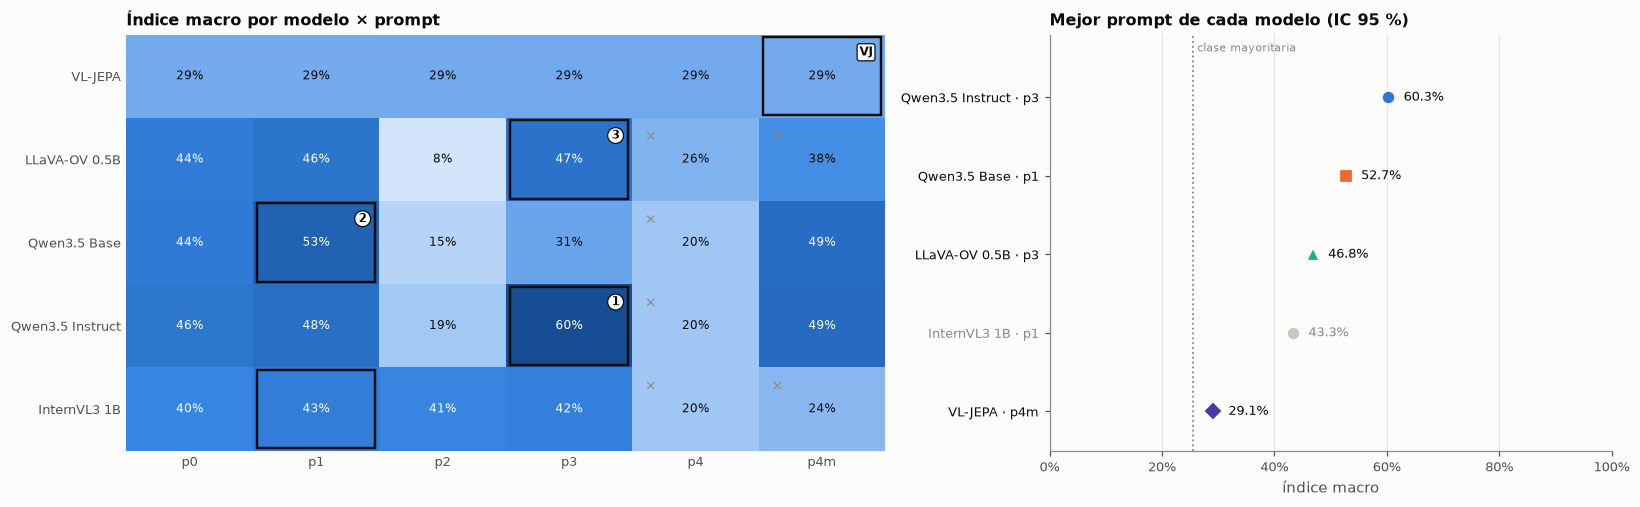

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 0.5 * len(MODEL_ORDER) + 2.2), gridspec_kw={"width_ratios": [1.35, 1]})
ax = axes[0]
Mx = pan.pivot_table(index="model", columns="prompt", values="macro").reindex(index=MODEL_ORDER, columns=PROMPT_ORDER)
heat(ax, Mx.values, [PS[p] for p in PROMPT_ORDER], [ML[m] for m in MODEL_ORDER], fmt="{:.0%}", vmin=0, vmax=max(0.7, np.nanmax(Mx.values)))
for run in best.index:
    i, j = MODEL_ORDER.index(pan.at[run, "model"]), PROMPT_ORDER.index(pan.at[run, "prompt"])
    ax.add_patch(plt.Rectangle((j - .47, i - .47), .94, .94, fill=False, ec=INK, lw=1.6))
    if run in TOP3 or run == VJ_RUN:
        lab_ = f"{TOP3.index(run) + 1}" if run in TOP3 else "VJ"
        ax.text(j + .40, i - .36, lab_, ha="right", va="top", fontsize=8, fontweight="bold", color=INK,
                bbox=dict(boxstyle="circle,pad=0.15" if run in TOP3 else "round,pad=0.2", fc=SURF, ec=INK, lw=0.8))
for run in excl:
    i, j = MODEL_ORDER.index(pan.at[run, "model"]), PROMPT_ORDER.index(pan.at[run, "prompt"])
    ax.text(j - .40, i - .36, "×", ha="left", va="top", fontsize=9, color=INK3)
ax.set_title("Índice macro por modelo × prompt", loc="left")

ax = axes[1]
yy = np.arange(len(ranking))
for k, run in enumerate(ranking.index):
    m, se = ranking.at[run, "macro"], ranking.at[run, "macro_se"]
    col = TC.get(run, NEUTRAL)
    ax.errorbar(m, k, xerr=Z * se, fmt=TMK.get(run, "o"), color=col, ms=9, mec=SURF, mew=1.5, capsize=0, elinewidth=2)
    ax.annotate(f"{m:.1%}", (m, k), xytext=(10, 0), textcoords="offset points", va="center", fontsize=8.5,
                color=INK if run in TOP_RUNS else INK3)
ax.axvline(MAJ["macro"], color=INK3, ls=":", lw=1.2)
ax.text(MAJ["macro"], -0.55, " clase mayoritaria", fontsize=7.5, color=INK3, va="bottom")
ax.set_yticks(yy, ranking.index)
for t, run in zip(ax.get_yticklabels(), ranking.index):
    t.set_color(INK if run in TOP_RUNS else INK3)
ax.invert_yaxis()
ax.set(xlim=(0, 1), ylim=(len(ranking) - 0.5, -0.8), xlabel="índice macro")
ax.xaxis.set_major_formatter(PCT); ax.grid(axis="y", visible=False)
ax.set_title("Mejor prompt de cada modelo (IC 95 %)", loc="left")
fig.tight_layout()
savefig(fig, "01_panorama_seleccion")
plt.show()

In [15]:
# Subconjunto de análisis: las configuraciones elegidas sobre las imágenes que tienen todas (pareado por construcción)
common_top = set.intersection(*(set(df.loc[df["run"] == r, "id"]) for r in TOP_RUNS))
top = df[df["run"].isin(TOP_RUNS) & df["id"].isin(common_top)].copy()
top["run"] = pd.Categorical(top["run"], categories=TOP_RUNS, ordered=True)
N_TOP = len(common_top)
print(f"{N_TOP:,} imágenes comunes a las {len(TOP_RUNS)} configuraciones analizadas: {TOP_RUNS}")

10,000 imágenes comunes a las 4 configuraciones analizadas: ['Qwen3.5 Instruct · p3', 'Qwen3.5 Base · p1', 'LLaVA-OV 0.5B · p3', 'VL-JEPA · p4m']


## 4. Perfil de las configuraciones analizadas

### 4.1 Texto

Antes de medir fidelidad conviene saber **qué tipo de texto** produce cada configuración: largo, diversidad (respuestas distintas / $N$;
un valor cercano a 0 indica una respuesta fija), respuestas probablemente truncadas (no terminan en puntuación de cierre), etiquetas
`<think>` y, en los prompts JSON, la fracción con un objeto JSON recuperable.

In [16]:
gt = top.groupby("run", observed=True)
txt = pd.DataFrame({
    "palabras P50": gt["n_words"].median(), "palabras P90": gt["n_words"].quantile(0.9),
    "respuestas distintas": gt["prediction"].nunique() / gt.size(),
    "truncadas": 1 - gt["ends_clean"].mean(), "<think>": gt["think"].mean(),
    "JSON válido": [gt.get_group(r)["json_ok"].astype(float).mean() if r in JSON_RUNS else np.nan for r in TOP_RUNS],
    "menciona forma": gt["shape_m"].mean(), "menciona posición": gt["pos_m"].mean(), "menciona color": gt["color_m"].mean(),
}).reindex(TOP_RUNS)
pct_cols = [c for c in txt.columns if not c.startswith("palabras")]
display(txt.style.format({c: "{:.1%}" for c in pct_cols} | {"palabras P50": "{:.0f}", "palabras P90": "{:.0f}"}, na_rep="–"))
save_table(txt, "texto_top")

freq_rows = []
for r in TOP_RUNS:
    vc = top.loc[top["run"] == r, "prediction"].map(lambda t: " ".join(strip_think_tags(t).split())).value_counts(normalize=True)
    for k, (t, f) in enumerate(vc.head(5).items(), 1):
        freq_rows.append({"corrida": r, "#": k, "respuesta": t[:140] + ("…" if len(t) > 140 else ""), "frecuencia": f})
display(pd.DataFrame(freq_rows).set_index(["corrida", "#"]).style.format({"frecuencia": "{:.2%}"})
        .set_caption("Las cinco respuestas más frecuentes de cada corrida"))

,palabras P50,palabras P90,respuestas distintas,truncadas,,JSON válido,menciona forma,menciona posición,menciona color
run,,,,,,,,,
Qwen3.5 Instruct · p3,9,25,7.4%,18.7%,0.0%,100.0%,99.9%,100.0%,100.0%
Qwen3.5 Base · p1,82,94,100.0%,29.5%,0.0%,–,61.8%,94.2%,99.6%
LLaVA-OV 0.5B · p3,8,8,1.1%,0.0%,0.0%,100.0%,98.2%,100.0%,96.8%
VL-JEPA · p4m,12,18,5.1%,0.0%,0.0%,–,100.0%,100.0%,100.0%


**Figura 2 — Largo de las respuestas** (palabras tras limpiar `<think>`; eje recortado al P99 conjunto).

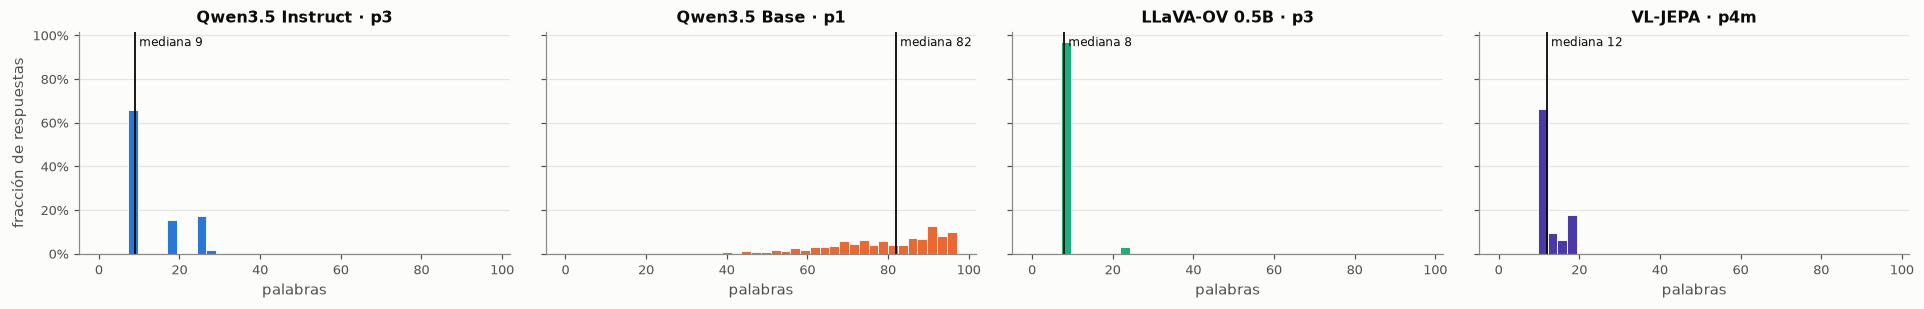

In [17]:
cap = np.nanpercentile(top["n_words"], 99)
bins = np.arange(0, cap + 2) - 0.5 if cap <= 60 else np.linspace(0, cap, 41)
fig, axes = plt.subplots(1, len(TOP_RUNS), figsize=(4.4 * len(TOP_RUNS), 2.9), sharey=True, squeeze=False)
for ax, r in zip(axes[0], TOP_RUNS):
    w = top.loc[top["run"] == r, "n_words"].clip(upper=cap)
    ax.hist(w, bins=bins, color=TC[r], edgecolor=SURF, linewidth=0.6, weights=np.full(len(w), 1 / len(w)))
    ax.axvline(w.median(), color=INK, lw=1.2)
    ax.text(w.median(), 0.98, f" mediana {w.median():.0f}", transform=ax.get_xaxis_transform(), fontsize=8, color=INK, va="top")
    ax.set(title=r, xlabel="palabras"); ax.yaxis.set_major_formatter(PCT); ax.grid(axis="x", visible=False)
axes[0, 0].set_ylabel("fracción de respuestas")
fig.tight_layout()
savefig(fig, "02_largo_respuestas")
plt.show()

### 4.2 Fidelidad por atributo

Para el atributo $a$: cobertura $\hat c_a=\frac1N\sum_i m_{i,a}$, exactitud $\hat\alpha_a=\frac1N\sum_i k_{i,a}$ (IC de Wilson) y
exactitud condicional $\hat\alpha^{\mid}_a=\hat\alpha_a/\hat c_a$, que aísla la calidad de lo que efectivamente se dice.

In [18]:
MENT = {"shape": "shape_m", "x": "x_m", "y": "y_m", "pos": "pos_m", "color": "color_m", "color_adj": "color_m", "name": "name_m"}
fid_rows = []
for r in TOP_RUNS:
    s = top[top["run"] == r]
    n = len(s)
    for a, col in ATT.items():
        k_, m_ = int(s[col].sum()), int(s[MENT[a]].sum())
        lo, hi = wilson(k_, n)
        fid_rows.append({"corrida": r, "atributo": a, "exactitud": k_ / n, "lo": float(lo), "hi": float(hi),
                         "cobertura": m_ / n, "condicional": k_ / m_ if m_ else np.nan})
    mac = s["macro"]
    fid_rows.append({"corrida": r, "atributo": "macro", "exactitud": mac.mean(),
                     "lo": mac.mean() - Z * mac.std(ddof=1) / np.sqrt(n), "hi": mac.mean() + Z * mac.std(ddof=1) / np.sqrt(n),
                     "cobertura": np.nan, "condicional": np.nan})
fid = pd.DataFrame(fid_rows)
fid_wide = fid.pivot(index="atributo", columns="corrida", values="exactitud").reindex(index=list(ATT_ES), columns=TOP_RUNS)
fid_wide.index = [ATT_ES[a] for a in fid_wide.index]
fid_wide["clase mayoritaria"] = [MAJ[a] for a in ATT_ES]
display(fid_wide.style.format("{:.1%}").background_gradient(cmap=SEQ, vmin=0, vmax=1, subset=TOP_RUNS)
        .set_caption("Exactitud estricta (omitir = error)"))
cond = fid.pivot(index="atributo", columns="corrida", values="condicional").reindex(index=list(ATT), columns=TOP_RUNS)
cov = fid.pivot(index="atributo", columns="corrida", values="cobertura").reindex(index=list(ATT), columns=TOP_RUNS)
cc = pd.concat({"cobertura": cov, "exactitud condicional": cond}, axis=1).rename(index=ATT_ES)
display(cc.style.format("{:.1%}", na_rep="–"))
save_table(fid, "fidelidad_top_largo", index=False)

corrida,Qwen3.5 Instruct · p3,Qwen3.5 Base · p1,LLaVA-OV 0.5B · p3,VL-JEPA · p4m,clase mayoritaria
Forma,43.5%,17.3%,37.7%,26.7%,14.5%
Posición x,62.1%,64.9%,33.2%,42.5%,34.3%
Posición y,62.3%,57.6%,33.3%,35.7%,33.9%
"Posición (x,y)",38.3%,43.0%,11.4%,16.1%,11.9%
Color (categoría),69.5%,68.8%,55.5%,20.4%,24.7%
Color ±1,99.0%,97.8%,91.5%,44.5%,50.3%
Nombre exacto,5.5%,5.7%,4.6%,1.9%,5.8%
Índice macro,60.3%,52.7%,46.8%,29.1%,25.6%


**Figura 3 — Exactitud por atributo con IC 95 %.** Cada fila es un atributo y cada marca, una corrida; la marca gris `|` es la exactitud de
responder siempre la clase mayoritaria. Con $N=10^4$ los IC miden ±1 pp: las barras de error casi no se ven.

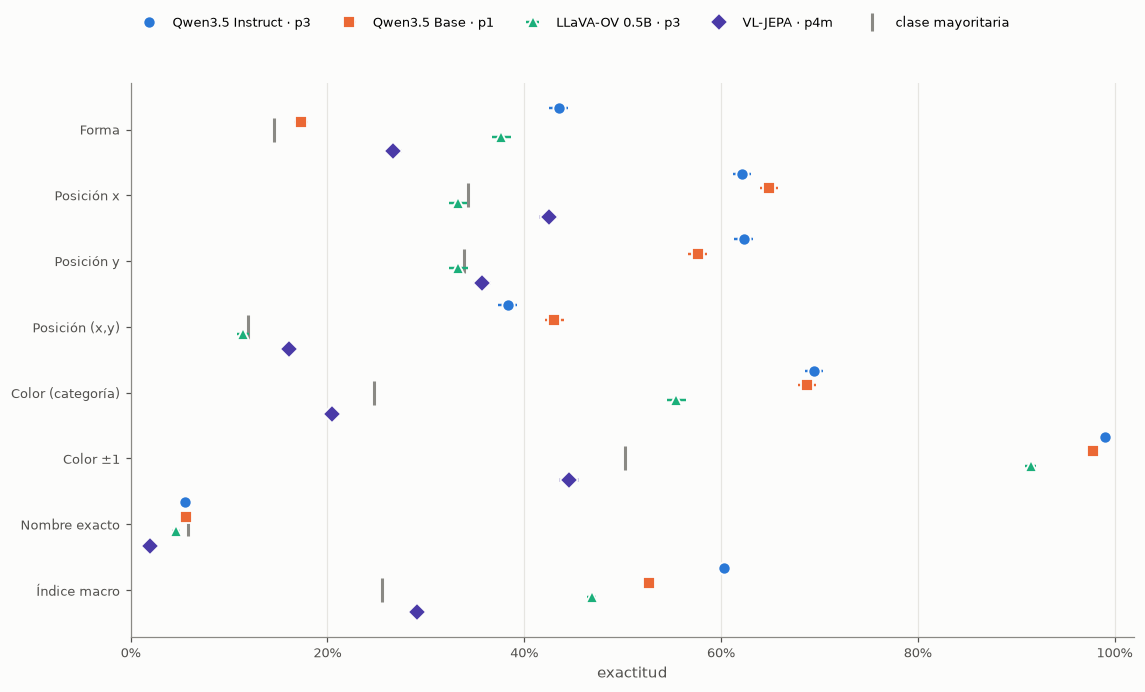

In [19]:
attrs_plot = list(ATT_ES)
fig, ax = plt.subplots(figsize=(10.5, 0.62 * len(attrs_plot) + 1.4))
off = {r: (k - (len(TOP_RUNS) - 1) / 2) * 0.22 for k, r in enumerate(TOP_RUNS)}
for yi, a in enumerate(attrs_plot):
    ax.plot(MAJ[a], yi, "|", color=INK3, ms=16, mew=2, zorder=1)
    for r in TOP_RUNS:
        row = fid[(fid["corrida"] == r) & (fid["atributo"] == a)].iloc[0]
        ax.errorbar(row["exactitud"], yi + off[r], xerr=[[row["exactitud"] - row["lo"]], [row["hi"] - row["exactitud"]]],
                    fmt=TMK[r], color=TC[r], ms=8, mec=SURF, mew=1.2, elinewidth=1.6, capsize=0, zorder=3,
                    label=r if yi == 0 else None)
ax.set_yticks(range(len(attrs_plot)), [ATT_ES[a] for a in attrs_plot]); ax.invert_yaxis()
ax.set(xlim=(0, 1.02), xlabel="exactitud"); ax.xaxis.set_major_formatter(PCT); ax.grid(axis="y", visible=False)
h, l = ax.get_legend_handles_labels()
h.append(plt.Line2D([], [], marker="|", ls="", color=INK3, ms=12, mew=2)); l.append("clase mayoritaria")
fig.tight_layout(rect=(0, 0, 1, 0.9))
fig.legend(h, l, loc="upper center", ncol=len(l), bbox_to_anchor=(0.5, 0.99))
savefig(fig, "03_exactitud_atributos")
plt.show()

**Figura 4 — Descomposición del resultado.** Para cada atributo, fracción de imágenes en que el atributo se dice y es *correcto*, se dice y
es *incorrecto*, o se *omite*. Distingue "no lo percibe" (incorrecto) de "no lo menciona" (omitido).

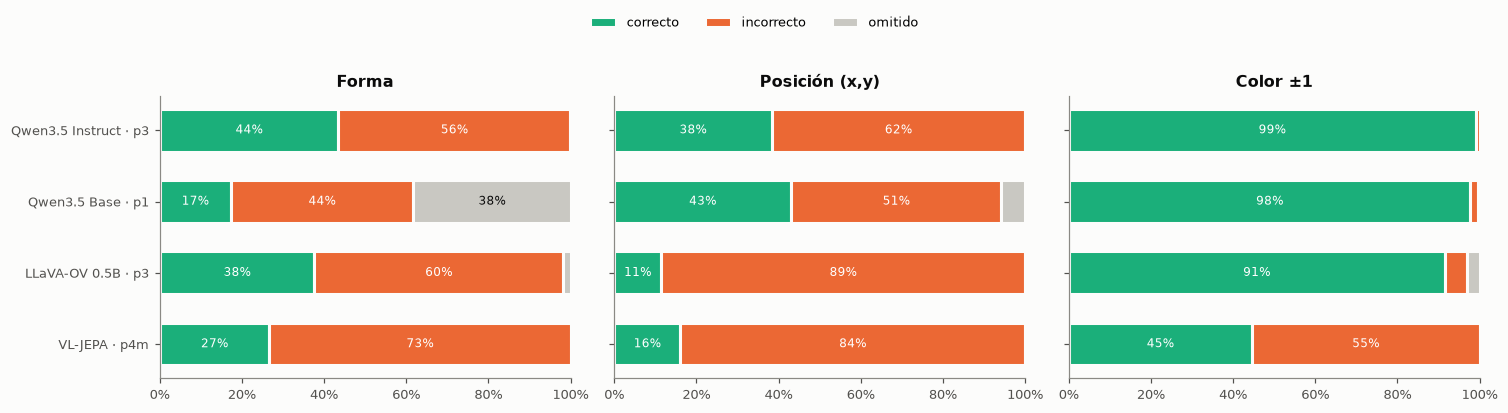

In [20]:
dec_att = [("shape", "Forma"), ("pos", "Posición (x,y)"), ("color_adj", "Color ±1")]
OUTC = [("correcto", SERIES[2]), ("incorrecto", SERIES[1]), ("omitido", NEUTRAL)]
fig, axes = plt.subplots(1, len(dec_att), figsize=(4.6 * len(dec_att), 0.55 * len(TOP_RUNS) + 1.6), sharey=True)
for ax, (a, lab) in zip(axes, dec_att):
    for k, r in enumerate(TOP_RUNS):
        s = top[top["run"] == r]
        ok, ment = s[ATT[a]].mean(), s[MENT[a]].mean()
        vals = [ok, ment - ok, 1 - ment]
        left = 0
        for (name, col), v in zip(OUTC, vals):
            ax.barh(k, v, left=left, color=col, height=0.6, edgecolor=SURF, linewidth=2, label=name if k == 0 else None)
            if v >= 0.07:
                ax.text(left + v / 2, k, f"{v:.0%}", ha="center", va="center", fontsize=8,
                        color="white" if name != "omitido" else INK)
            left += v
    ax.set(xlim=(0, 1), title=lab); ax.xaxis.set_major_formatter(PCT); ax.grid(False)
axes[0].set_yticks(range(len(TOP_RUNS)), TOP_RUNS); axes[0].invert_yaxis()
h, l = axes[0].get_legend_handles_labels()
fig.tight_layout(rect=(0, 0, 1, 0.86))
fig.legend(h, l, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 0.99))
savefig(fig, "04_descomposicion")
plt.show()

## 5. Análisis de errores

### 5.1 Forma

Matriz de confusión normalizada por fila, $\hat P(\hat s=j\mid s=i)$, con una columna adicional $\varnothing$ para la omisión. La diagonal es
la sensibilidad por clase; una columna cargada fuera de la diagonal revela un **sesgo de respuesta** (el modelo nombra una clase por defecto).

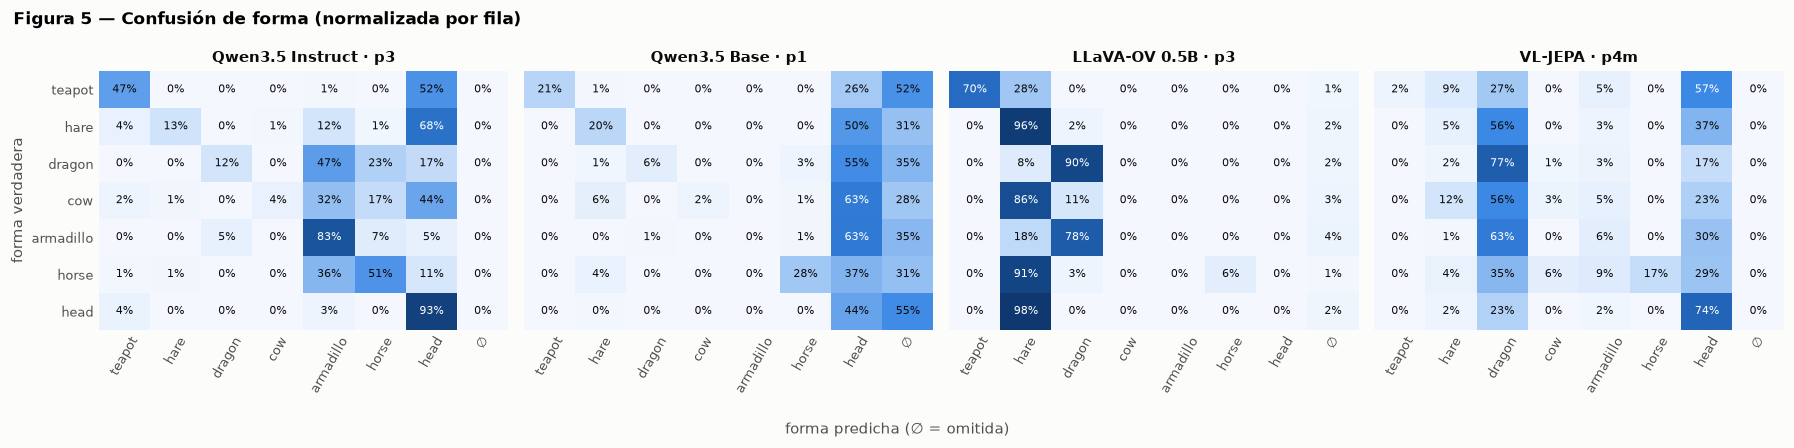

In [21]:
SHAPES = [SHAPE_NAMES[k] for k in sorted(SHAPE_NAMES)]
fig, axes = plt.subplots(1, len(TOP_RUNS), figsize=(4.1 * len(TOP_RUNS), 4.0), sharey=True, squeeze=False)
for ax, r in zip(axes[0], TOP_RUNS):
    s = top[top["run"] == r]
    ct = pd.crosstab(s["shape_true"], s["shape"].fillna("∅")).reindex(index=SHAPES, columns=SHAPES + ["∅"], fill_value=0)
    heat(ax, ct.div(ct.sum(axis=1), axis=0).values, SHAPES + ["∅"], SHAPES, fmt="{:.0%}", fontsize=7)
    ax.tick_params(axis="x", rotation=60)
    ax.set_title(r, fontsize=9.5)
axes[0, 0].set_ylabel("forma verdadera")
fig.supxlabel("forma predicha (∅ = omitida)", fontsize=9.5, color=INK2)
fig.suptitle("Figura 5 — Confusión de forma (normalizada por fila)", x=0.01, ha="left", fontweight="semibold")
fig.tight_layout()
savefig(fig, "05_confusion_forma")
plt.show()

**Figura 6 — Sensibilidad por clase y sesgo de respuesta.** Izquierda: $\hat P(\hat s=s\mid s)$ por forma verdadera (línea punteada: azar,
$1/7$). Derecha: distribución de las formas **predichas**; con clases equilibradas, una barra muy por encima de $1/7$ es una clase "comodín".

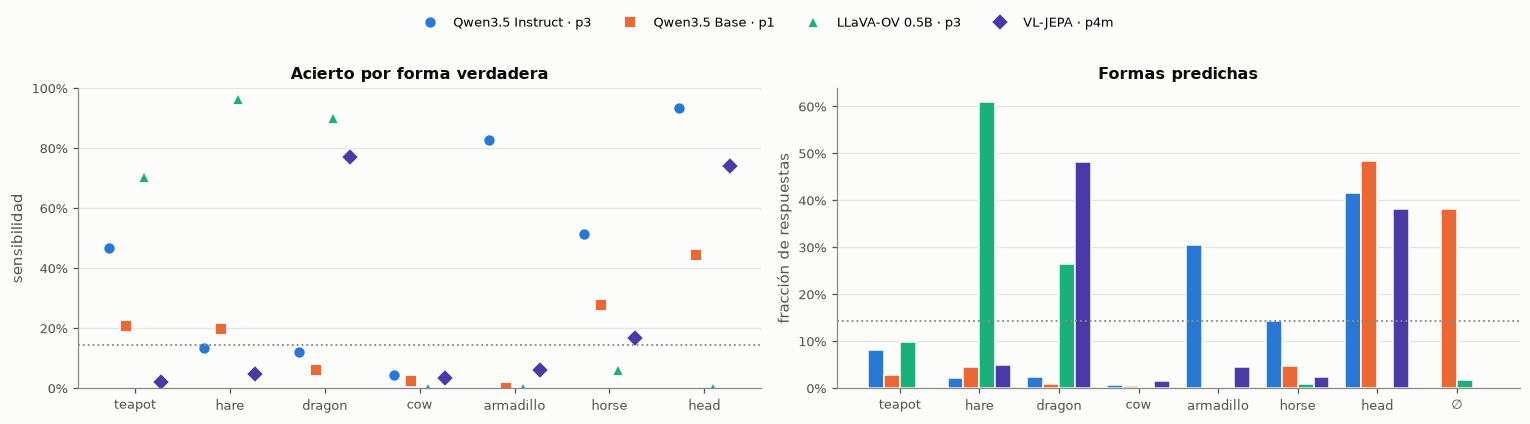

,verdadera → predicha,n,% de la clase
corrida,,,
Qwen3.5 Instruct · p3,hare → head,976,67.8%
Qwen3.5 Instruct · p3,teapot → head,733,52.3%
Qwen3.5 Instruct · p3,dragon → armadillo,687,47.4%
Qwen3.5 Instruct · p3,cow → head,613,43.6%
Qwen3.5 Instruct · p3,horse → armadillo,505,35.5%
Qwen3.5 Base · p1,armadillo → head,903,63.3%
Qwen3.5 Base · p1,cow → head,884,62.9%
Qwen3.5 Base · p1,dragon → head,792,54.7%
Qwen3.5 Base · p1,hare → head,716,49.7%


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3.9))
xs = np.arange(len(SHAPES))
w = 0.8 / len(TOP_RUNS)
for k, r in enumerate(TOP_RUNS):
    s = top[top["run"] == r]
    rec = s.groupby("shape_true")["shape_ok"].mean().reindex(SHAPES)
    axes[0].plot(xs + (k - (len(TOP_RUNS) - 1) / 2) * 0.18, rec.values, TMK[r], color=TC[r], ms=8, mec=SURF, mew=1.2, ls="", label=r)
    pd_ = s["shape"].fillna("∅").value_counts(normalize=True).reindex(SHAPES + ["∅"], fill_value=0)
    axes[1].bar(np.arange(len(SHAPES) + 1) + (k - (len(TOP_RUNS) - 1) / 2) * w, pd_.values, width=w, color=TC[r],
                edgecolor=SURF, linewidth=1)
axes[0].axhline(1 / 7, color=INK3, ls=":", lw=1.2)
axes[0].set_xticks(xs, SHAPES); axes[0].set(ylim=(0, 1), ylabel="sensibilidad", title="Acierto por forma verdadera")
axes[0].yaxis.set_major_formatter(PCT); axes[0].grid(axis="x", visible=False)
axes[1].axhline(1 / 7, color=INK3, ls=":", lw=1.2)
axes[1].set_xticks(np.arange(len(SHAPES) + 1), SHAPES + ["∅"])
axes[1].set(ylabel="fracción de respuestas", title="Formas predichas"); axes[1].yaxis.set_major_formatter(PCT)
axes[1].grid(axis="x", visible=False)
h, l = axes[0].get_legend_handles_labels()
fig.tight_layout(rect=(0, 0, 1, 0.88))
fig.legend(h, l, loc="upper center", ncol=len(l), bbox_to_anchor=(0.5, 0.99))
savefig(fig, "06_forma_por_clase")
plt.show()

conf_rows = []
for r in TOP_RUNS:
    s = top[(top["run"] == r) & top["shape_m"] & ~top["shape_ok"]]
    n_cls = top[top["run"] == r].groupby("shape_true").size()
    for (t, p_), n in s.groupby(["shape_true", "shape"]).size().sort_values(ascending=False).head(5).items():
        conf_rows.append({"corrida": r, "verdadera → predicha": f"{t} → {p_}", "n": n, "% de la clase": n / n_cls[t]})
display(pd.DataFrame(conf_rows).set_index("corrida").style.format({"% de la clase": "{:.1%}", "n": "{:,}"})
        .set_caption("Cinco confusiones de forma más frecuentes"))

### 5.2 Posición

**Figura 7.** Por corrida (filas): exactitud de la posición conjunta según la celda verdadera, dispuesta como en la imagen (arriba = *top*,
izquierda = *left*), y las matrices de confusión de cada eje por separado. Un error sistemático en un solo eje (p. ej. confundir *mid* con
*bottom*) aparece como masa fuera de la diagonal en una sola de las dos matrices.

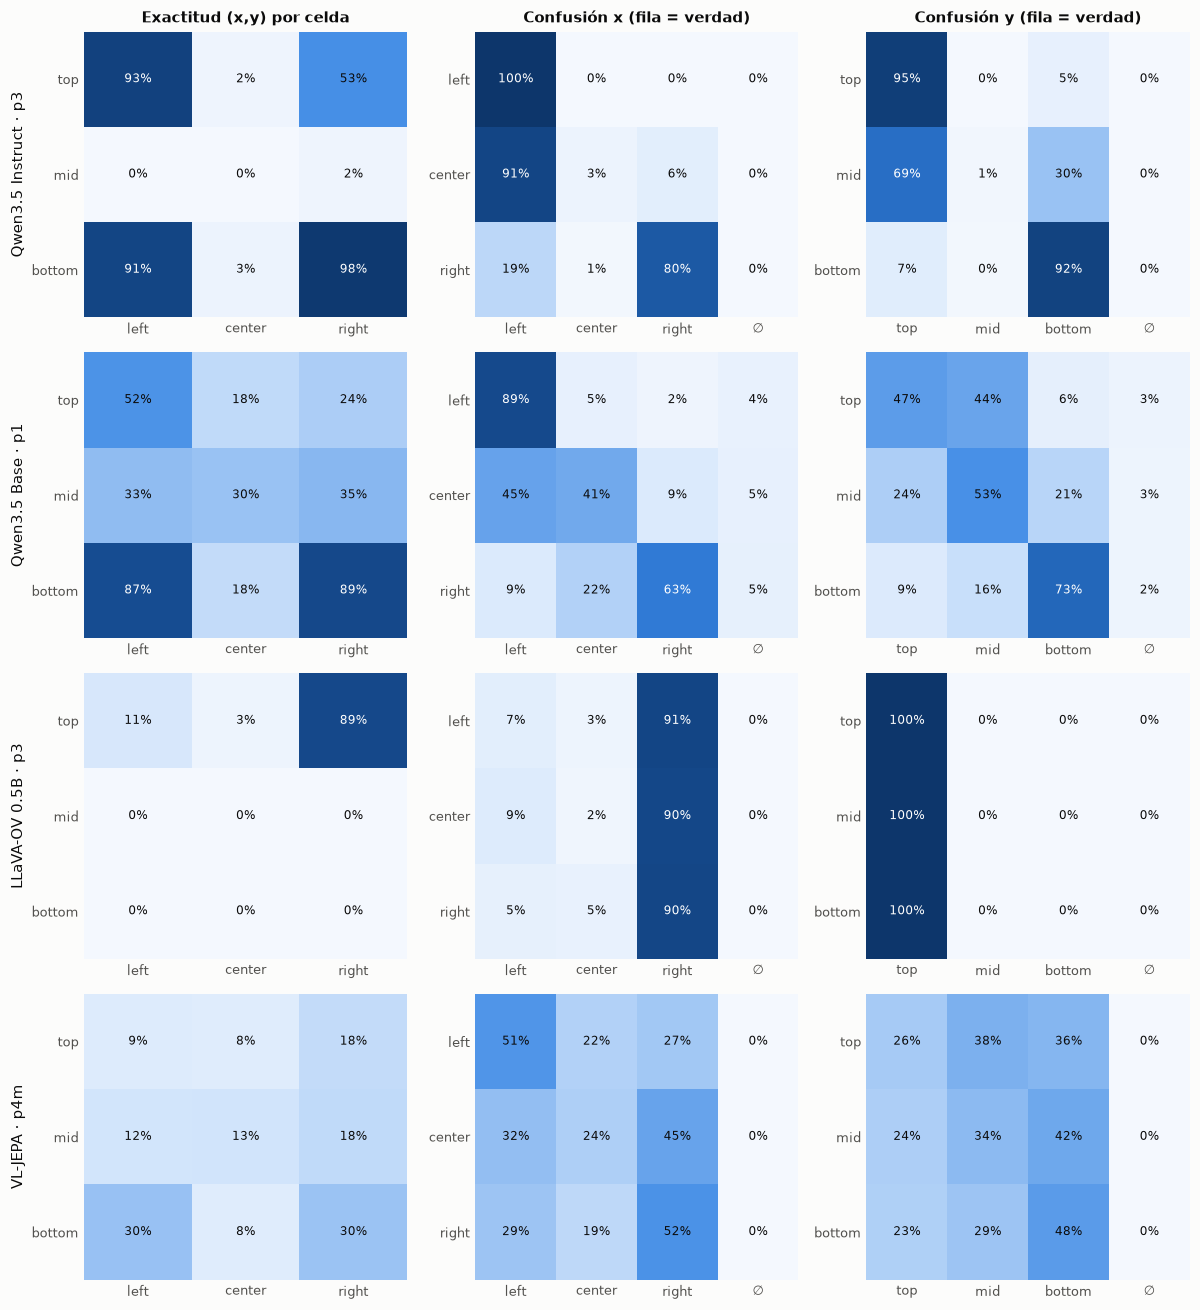

In [23]:
XS, YS = ["left", "center", "right"], ["top", "mid", "bottom"]
fig, axes = plt.subplots(len(TOP_RUNS), 3, figsize=(11, 3.0 * len(TOP_RUNS)), squeeze=False)
for k, r in enumerate(TOP_RUNS):
    s = top[top["run"] == r]
    G = s.pivot_table(index="y_true", columns="x_true", values="pos_ok", aggfunc="mean").reindex(index=YS, columns=XS)
    heat(axes[k, 0], G.values, XS, YS, fontsize=8)
    cx = pd.crosstab(s["x_true"], s["xpos"].fillna("∅")).reindex(index=XS, columns=XS + ["∅"], fill_value=0)
    heat(axes[k, 1], cx.div(cx.sum(axis=1), axis=0).values, XS + ["∅"], XS, fontsize=8)
    cy = pd.crosstab(s["y_true"], s["ypos"].fillna("∅")).reindex(index=YS, columns=YS + ["∅"], fill_value=0)
    heat(axes[k, 2], cy.div(cy.sum(axis=1), axis=0).values, YS + ["∅"], YS, fontsize=8)
    axes[k, 0].set_ylabel(r, fontsize=9.5, color=INK)
for ax, t in zip(axes[0], ["Exactitud (x,y) por celda", "Confusión x (fila = verdad)", "Confusión y (fila = verdad)"]):
    ax.set_title(t, fontsize=9.5)
fig.tight_layout()
savefig(fig, "07_posicion")
plt.show()

### 5.3 Color

**Figura 8.** Arriba: exactitud de color ±1 según el tono verdadero $h$ (24 intervalos; líneas punteadas = límites de categoría).
Abajo izquierda: función de distribución empírica del error angular $|\Delta\theta|=360\,\big|((\hat h-h+\tfrac12)\bmod 1)-\tfrac12\big|$ entre el
tono del color nombrado y el verdadero (solo respuestas con un color cromático); una curva más a la izquierda es mejor. Abajo derecha:
fracción de los errores de color en que la categoría nombrada coincide con la del **fondo**, frente a lo esperado si fuera azar
(permutando los fondos).

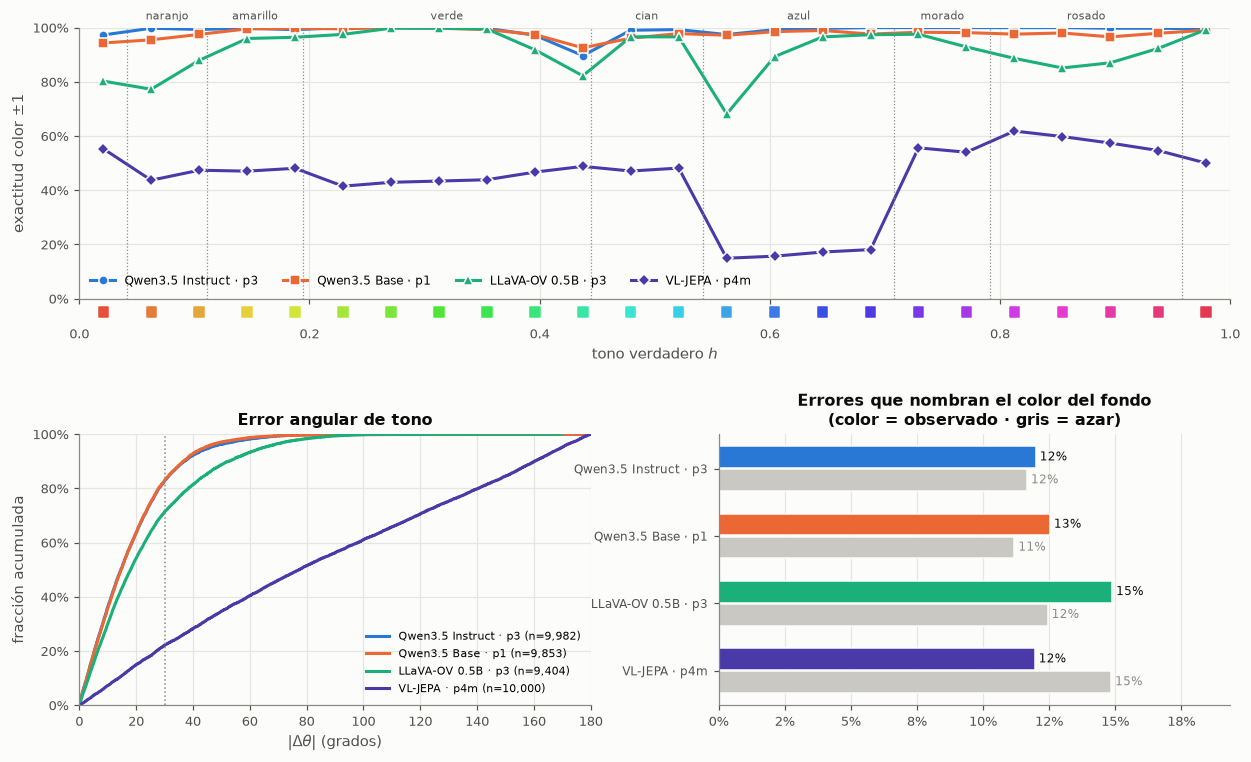

,errores de color,= categoría del fondo,esperado por azar
corrida,,,
Qwen3.5 Instruct · p3,"3,035",12.0%,11.7%
Qwen3.5 Base · p1,"2,977",12.5%,11.2%
LLaVA-OV 0.5B · p3,"3,857",14.9%,12.4%
VL-JEPA · p4m,"7,956",12.0%,14.8%


In [24]:
bins = np.linspace(0, 1, 25); centers = (bins[:-1] + bins[1:]) / 2
fig = plt.figure(figsize=(13.5, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], hspace=0.5, wspace=0.25)
ax = fig.add_subplot(gs[0, :])
for r in TOP_RUNS:
    s = top[top["run"] == r]
    b = np.clip(np.digitize(s["object_color"], bins) - 1, 0, len(centers) - 1)
    accb = s.groupby(b)["color_adj"].mean().reindex(range(len(centers)))
    ax.plot(centers, accb.values, marker=TMK[r], color=TC[r], ms=6, mec=SURF, label=r)
for u in HUE_UPPER:
    ax.axvline(u / 360, color=INK3, lw=0.8, ls=":")
lims = [0] + [u / 360 for u in HUE_UPPER[:-1]] + [HUE_UPPER[-1] / 360]
for c, lo, hi in zip(COLOR_CATS[1:], lims[1:-1], lims[2:]):
    ax.text((lo + hi) / 2, 1.03, COLOR_ES[c], ha="center", fontsize=7.5, color=INK2, transform=ax.get_xaxis_transform())
ax.scatter(centers, np.full_like(centers, -0.05), c=[colorsys.hsv_to_rgb(h, .75, .9) for h in centers], s=38, marker="s",
           transform=ax.get_xaxis_transform(), clip_on=False)
ax.tick_params(axis="x", pad=16)
ax.set(xlim=(0, 1), ylim=(0, 1.0), xlabel="tono verdadero $h$", ylabel="exactitud color ±1")
ax.yaxis.set_major_formatter(PCT)
ax.legend(loc="lower left", ncol=len(TOP_RUNS), fontsize=8)

ax = fig.add_subplot(gs[1, 0])
for r in TOP_RUNS:
    e = np.sort(top.loc[(top["run"] == r) & top["hue_err"].notna(), "hue_err"].values)
    if len(e):
        ax.step(e, np.arange(1, len(e) + 1) / len(e), where="post", color=TC[r], lw=2, label=f"{r} (n={len(e):,})")
ax.axvline(30, color=INK3, ls=":", lw=1)
ax.set(xlim=(0, 180), ylim=(0, 1), xlabel="$|\\Delta\\theta|$ (grados)", ylabel="fracción acumulada",
       title="Error angular de tono")
ax.yaxis.set_major_formatter(PCT); ax.legend(fontsize=7.5, loc="lower right")

ax = fig.add_subplot(gs[1, 1])
bg_rows = []
perm_bg = RNG.permutation(truth["background_color"].values)
bg_null_map = dict(zip(truth["id"], [hue_to_cat(h) for h in perm_bg]))
for k, r in enumerate(TOP_RUNS):
    s = top[(top["run"] == r) & top["color_m"] & ~top["color_ok"] & top["color_cat"].isin(COLOR_CATS)]
    if s.empty:
        continue
    obs = (s["color_cat"] == s["background_color"].map(hue_to_cat)).mean()
    null = (s["color_cat"] == s["id"].map(bg_null_map)).mean()
    bg_rows.append({"corrida": r, "errores de color": len(s), "= categoría del fondo": obs, "esperado por azar": null})
    ax.barh(k - 0.17, obs, height=0.32, color=TC[r], edgecolor=SURF, linewidth=1)
    ax.barh(k + 0.17, null, height=0.32, color=NEUTRAL, edgecolor=SURF, linewidth=1)
    ax.text(obs, k - 0.17, f" {obs:.0%}", va="center", fontsize=8, color=INK)
    ax.text(null, k + 0.17, f" {null:.0%}", va="center", fontsize=8, color=INK3)
ax.set_yticks(range(len(TOP_RUNS)), [f"{r}" for r in TOP_RUNS], fontsize=8); ax.invert_yaxis()
xmax = max([max(r_["= categoría del fondo"], r_["esperado por azar"]) for r_ in bg_rows] + [0.1])
ax.set(xlim=(0, min(1, 1.3 * xmax)), title="Errores que nombran el color del fondo\n(color = observado · gris = azar)")
ax.xaxis.set_major_formatter(PCT); ax.grid(axis="y", visible=False)
savefig(fig, "08_color")
plt.show()
if bg_rows:
    display(pd.DataFrame(bg_rows).set_index("corrida").style.format({"= categoría del fondo": "{:.1%}", "esperado por azar": "{:.1%}",
                                                                    "errores de color": "{:,}"}))

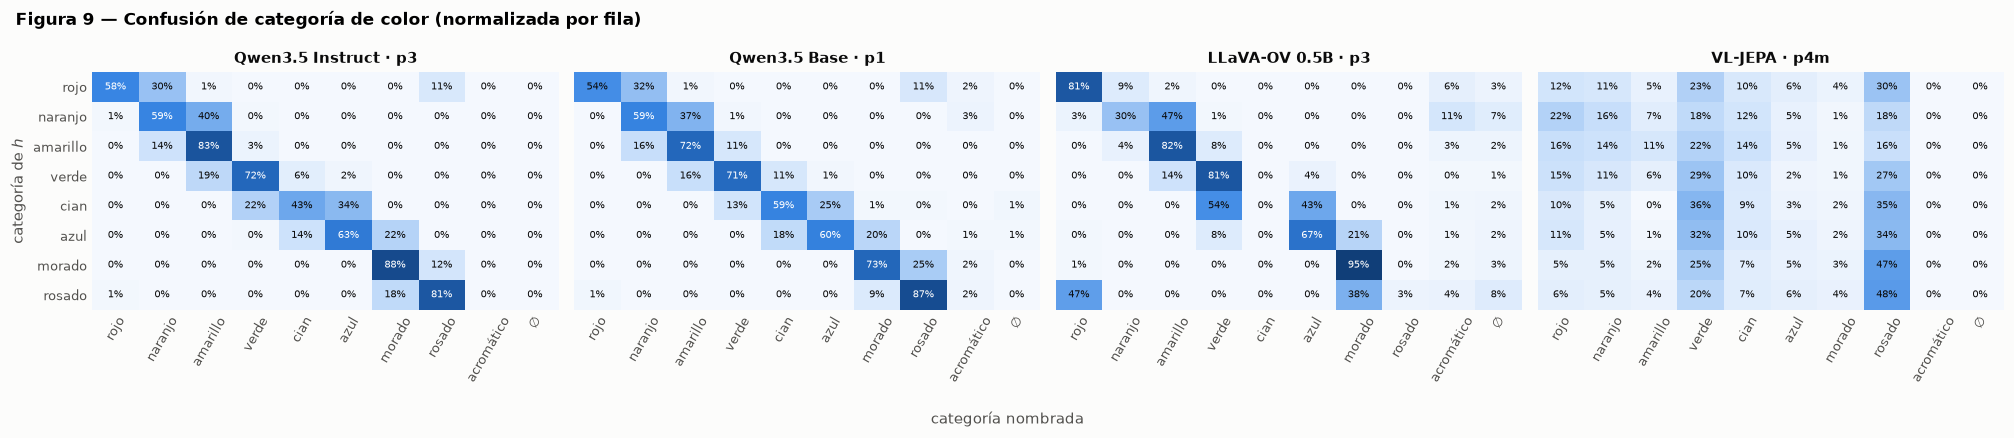

In [25]:
cols_ = COLOR_CATS + ["achromatic", "∅"]
fig, axes = plt.subplots(1, len(TOP_RUNS), figsize=(4.6 * len(TOP_RUNS), 3.9), sharey=True, squeeze=False)
for ax, r in zip(axes[0], TOP_RUNS):
    s = top[top["run"] == r]
    ct = pd.crosstab(s["cat_true"], s["color_cat"].fillna("∅")).reindex(index=COLOR_CATS, columns=cols_, fill_value=0)
    heat(ax, ct.div(ct.sum(axis=1), axis=0).values, [COLOR_ES.get(c, c) for c in cols_], [COLOR_ES[c] for c in COLOR_CATS],
         fontsize=6.5)
    ax.tick_params(axis="x", rotation=60)
    ax.set_title(r, fontsize=9.5)
axes[0, 0].set_ylabel("categoría de $h$")
fig.supxlabel("categoría nombrada", fontsize=9.5, color=INK2)
fig.suptitle("Figura 9 — Confusión de categoría de color (normalizada por fila)", x=0.01, ha="left", fontweight="semibold")
fig.tight_layout()
savefig(fig, "09_confusion_color")
plt.show()

### 5.4 Factores de dificultad

**Figura 10.** Exactitud según el **contraste de tono** entre objeto y fondo, $\Delta h=360\,\big|((h_{\text{obj}}-h_{\text{fondo}}+\tfrac12)\bmod1)-\tfrac12\big|\in[0°,180°]$
(barras = IC de Wilson), y exactitud de forma según la **celda** del objeto. Si el bajo contraste explica parte del error, la exactitud
debe crecer con $\Delta h$; si la forma se reconoce peor en los bordes, la grilla lo muestra.

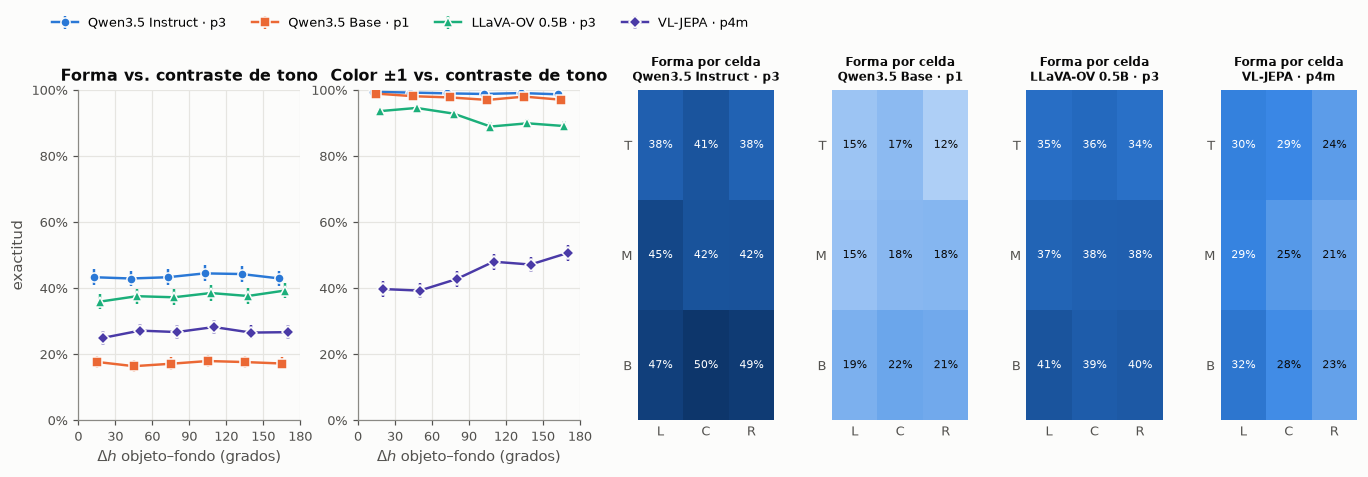

In [26]:
top["dh_bg"] = circ_deg(top["object_color"], top["background_color"])
dh_bins = np.arange(0, 181, 30)
top["dh_bin"] = pd.cut(top["dh_bg"], dh_bins, include_lowest=True)
fig = plt.figure(figsize=(15, 3.9))
gs = fig.add_gridspec(1, 2 + len(TOP_RUNS), width_ratios=[1.3, 1.3] + [0.8] * len(TOP_RUNS), wspace=0.35)
for j, (a, lab) in enumerate([("shape", "Forma"), ("color_adj", "Color ±1")]):
    ax = fig.add_subplot(gs[0, j])
    for k, r in enumerate(TOP_RUNS):
        s = top[top["run"] == r].groupby("dh_bin", observed=False)[ATT[a]].agg(["sum", "count"])
        p_ = s["sum"] / s["count"]
        lo, hi = wilson(s["sum"].values, s["count"].values)
        xc = (dh_bins[:-1] + dh_bins[1:]) / 2 + (k - 1) * 2.5
        ax.errorbar(xc, p_.values, yerr=[p_.values - lo, hi - p_.values], fmt=TMK[r] + "-", color=TC[r], ms=6, mec=SURF,
                    lw=1.6, capsize=0, label=r)
    ax.set(xlim=(0, 180), ylim=(0, 1), xlabel="$\\Delta h$ objeto–fondo (grados)", title=f"{lab} vs. contraste de tono")
    ax.set_xticks(dh_bins); ax.yaxis.set_major_formatter(PCT)
    if j == 0:
        ax.set_ylabel("exactitud")
        h, l = ax.get_legend_handles_labels()
GRIDS = {r: top[top["run"] == r].pivot_table(index="y_true", columns="x_true", values="shape_ok", aggfunc="mean")
         .reindex(index=YS, columns=XS) for r in TOP_RUNS}
VMAX_G = max(0.5, max(float(np.nanmax(G.values)) for G in GRIDS.values()))     # misma escala para todas
for k, r in enumerate(TOP_RUNS):
    ax = fig.add_subplot(gs[0, 2 + k])
    heat(ax, GRIDS[r].values, ["L", "C", "R"], ["T", "M", "B"], fontsize=7.5, vmin=0, vmax=VMAX_G)
    ax.set_title(f"Forma por celda\n{r}", fontsize=8)
fig.legend(h, l, loc="upper center", ncol=len(l), bbox_to_anchor=(0.32, 1.08))
savefig(fig, "10_dificultad")
plt.show()

## 6. Comparación pareada, errores compartidos y texto vs. fidelidad

### 6.1 Contrastes pareados

Todas las configuraciones se evalúan sobre **las mismas imágenes**, así que las exactitudes se comparan con **McNemar exacto**: con
$b=\#\{a\text{ falla},\,b\text{ acierta}\}$ y $c=\#\{a\text{ acierta},\,b\text{ falla}\}$, bajo $H_0$ $b\sim\mathrm{Bin}(b+c,\tfrac12)$. Los
$p$-valores se ajustan por Holm–Bonferroni sobre todas las comparaciones de la tabla. El índice macro (no binario) se compara con la
diferencia pareada de medias y su IC normal.

El **κ de Cohen** entre las formas *predichas* mide si dos configuraciones dicen lo mismo más allá del azar: un κ alto con exactitudes bajas
indica que **cometen los mismos errores**.

In [27]:
pairs = [(TOP_RUNS[i], TOP_RUNS[j]) for i in range(len(TOP_RUNS)) for j in range(i + 1, len(TOP_RUNS))]
W = {a: top.pivot_table(index="id", columns="run", values=ATT[a], aggfunc="first", observed=False) for a in ["shape", "pos", "color_adj", "name"]}
SH_PRED = top.pivot_table(index="id", columns="run", values="shape", aggfunc="first", observed=False).fillna("∅")


def cohen_kappa(u, v):
    cats = sorted(set(u) | set(v))
    ct = pd.crosstab(pd.Categorical(u, cats), pd.Categorical(v, cats), dropna=False).values.astype(float)
    n = ct.sum()
    po, pe = np.trace(ct) / n, (ct.sum(0) @ ct.sum(1)) / n ** 2
    return (po - pe) / (1 - pe) if pe < 1 else np.nan


pw = []
for ra, rb in pairs:
    for a in ["shape", "pos", "color_adj", "name"]:
        A, B = W[a][ra].astype(bool).values, W[a][rb].astype(bool).values
        b_, c_ = int((~A & B).sum()), int((A & ~B).sum())
        pw.append({"A": ra, "B": rb, "atributo": ATT_ES[a], "exactitud A": A.mean(), "exactitud B": B.mean(),
                   "Δ (B−A)": B.mean() - A.mean(), "b": b_, "c": c_, "p": mcnemar_exact(b_, c_)})
    m, lo, hi = paired_diff(rb, ra)
    pw.append({"A": ra, "B": rb, "atributo": "Índice macro", "exactitud A": M_by[ra].mean(), "exactitud B": M_by[rb].mean(),
               "Δ (B−A)": m, "b": np.nan, "c": np.nan, "p": 2 * (1 - 0.5 * (1 + math.erf(abs(m) / ((hi - lo) / (2 * Z)) / math.sqrt(2))))})
pw = pd.DataFrame(pw)
pw["p_holm"] = holm(pw["p"])
pw["sig."] = np.where(pw["p_holm"] < ALPHA, "✓", "")
display(pw.set_index(["A", "B", "atributo"]).style.format(
    {"exactitud A": "{:.1%}", "exactitud B": "{:.1%}", "Δ (B−A)": "{:+.1%}", "b": "{:,.0f}", "c": "{:,.0f}", "p": "{:.2g}",
     "p_holm": "{:.2g}"}, na_rep="–").background_gradient(cmap=DIV, subset=["Δ (B−A)"], vmin=-0.4, vmax=0.4))
save_table(pw, "pareadas_top", index=False)

kap = pd.DataFrame(np.nan, index=TOP_RUNS, columns=TOP_RUNS)
for ra, rb in pairs:
    kap.loc[ra, rb] = kap.loc[rb, ra] = cohen_kappa(SH_PRED[ra].values, SH_PRED[rb].values)
display(kap.style.format("{:.2f}", na_rep="–").set_caption("κ de Cohen entre las formas predichas"))

,Qwen3.5 Instruct · p3,Qwen3.5 Base · p1,LLaVA-OV 0.5B · p3,VL-JEPA · p4m
Qwen3.5 Instruct · p3,–,0.14,0.08,0.11
Qwen3.5 Base · p1,0.14,–,0.05,0.02
LLaVA-OV 0.5B · p3,0.08,0.05,–,0.08
VL-JEPA · p4m,0.11,0.02,0.08,–


### 6.2 ¿Fallan en las mismas imágenes?

**Figura 11.** Número de configuraciones que aciertan cada imagen, $S_i=\sum_r k_{i,r}\in\{0,\dots,3\}$, frente a la distribución esperada si
los aciertos fueran **independientes** entre configuraciones (Poisson-binomial con las exactitudes marginales). Un exceso en $S=0$ y
$S=3$ indica dificultad **compartida**: hay imágenes intrínsecamente difíciles (o fáciles) para todos los modelos.

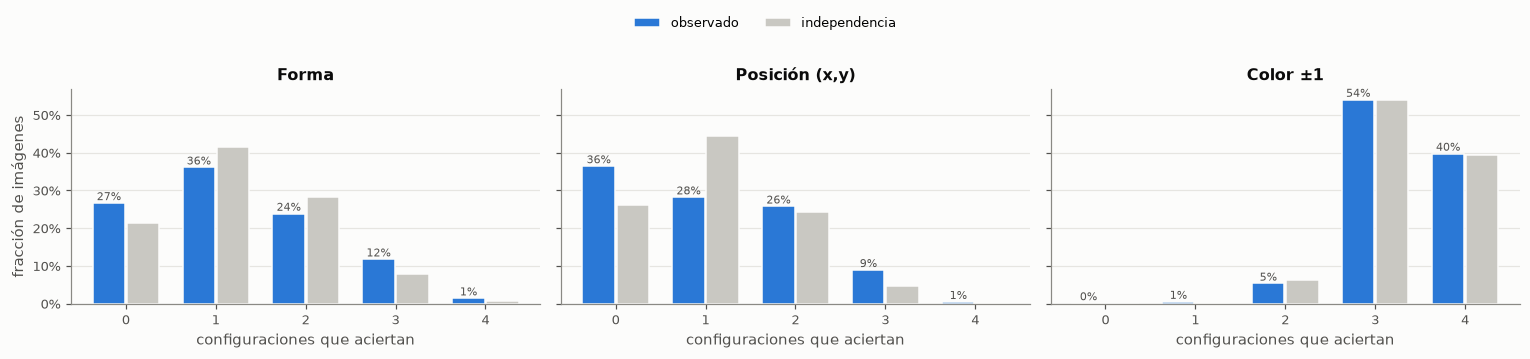

,P(S=0) obs.,P(S=0) indep.,P(S=4) obs.,P(S=4) indep.,z (S=0),p (S=0)
atributo,,,,,,
Forma,26.7%,21.4%,1.5%,0.8%,+13.1,4.7e-39
"Posición (x,y)",36.5%,26.1%,0.5%,0.3%,+23.5,1.4e-122
Color ±1,0.2%,0.0%,39.8%,39.4%,+55.1,0


In [28]:
def poisson_binomial(ps):
    dist = np.array([1.0])
    for p in ps:
        dist = np.convolve(dist, [1 - p, p])
    return dist


fig, axes = plt.subplots(1, 3, figsize=(14, 3.3), sharey=True)
shared_rows = []
for ax, a in zip(axes, ["shape", "pos", "color_adj"]):
    Wa = W[a][TOP_RUNS].astype(bool)
    obs = Wa.sum(axis=1).value_counts(normalize=True).reindex(range(len(TOP_RUNS) + 1), fill_value=0)
    ind = poisson_binomial(Wa.mean().values)
    xk = np.arange(len(TOP_RUNS) + 1)
    ax.bar(xk - 0.19, obs.values, width=0.36, color=SERIES[0], edgecolor=SURF, linewidth=1, label="observado")
    ax.bar(xk + 0.19, ind, width=0.36, color=NEUTRAL, edgecolor=SURF, linewidth=1, label="independencia")
    for x_, v in zip(xk, obs.values):
        ax.text(x_ - 0.19, v, f"{v:.0%}", ha="center", va="bottom", fontsize=7.5, color=INK2)
    ax.set_xticks(xk, [str(k) for k in xk]); ax.set(title=ATT_ES[a], xlabel="configuraciones que aciertan")
    ax.yaxis.set_major_formatter(PCT); ax.grid(axis="x", visible=False)
    # z para P(S=0) frente a independencia (aprox. normal; las marginales se tratan como conocidas)
    z0 = (obs.iloc[0] - ind[0]) / math.sqrt(max(ind[0] * (1 - ind[0]), 1e-12) / len(Wa))
    shared_rows.append({"atributo": ATT_ES[a], "P(S=0) obs.": obs.iloc[0], "P(S=0) indep.": ind[0],
                        f"P(S={len(TOP_RUNS)}) obs.": obs.iloc[-1], f"P(S={len(TOP_RUNS)}) indep.": ind[-1],
                        "z (S=0)": z0, "p (S=0)": math.erfc(abs(z0) / math.sqrt(2))})
axes[0].set_ylabel("fracción de imágenes")
h, l = axes[0].get_legend_handles_labels()
fig.tight_layout(rect=(0, 0, 1, 0.86))
fig.legend(h, l, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 0.99))
savefig(fig, "11_errores_compartidos")
plt.show()
shared = pd.DataFrame(shared_rows).set_index("atributo")
display(shared.style.format({c: "{:.1%}" for c in shared.columns if c.startswith("P(")} | {"z (S=0)": "{:+.1f}", "p (S=0)": "{:.2g}"}))

### 6.3 Métricas de texto vs. fidelidad

Las respuestas JSON (p3) no se parecen textualmente a la referencia por diseño. Para compararlas con justicia se reporta además una versión
**normalizada**: cada JSON válido se reescribe en la plantilla del dataset,
`A "<color>" <shape> is at the <vertical>-<horizontal> of the image.`, con los valores tal como los dio el modelo (las respuestas no JSON
quedan igual). La línea base **referencia permutada** asigna a cada imagen la referencia de *otra* imagen: es una descripción
perfectamente formateada pero sin relación con la escena.

**Figura 12.** CIDEr-D por imagen (texto normalizado) según el número de atributos correctos ($3M_i\in\{0,1,2,3\}$), con IC 95 % de la media.
Si las métricas de texto reflejaran fidelidad, la curva crecería con fuerza; $\rho_s$ es la correlación de Spearman por imagen.

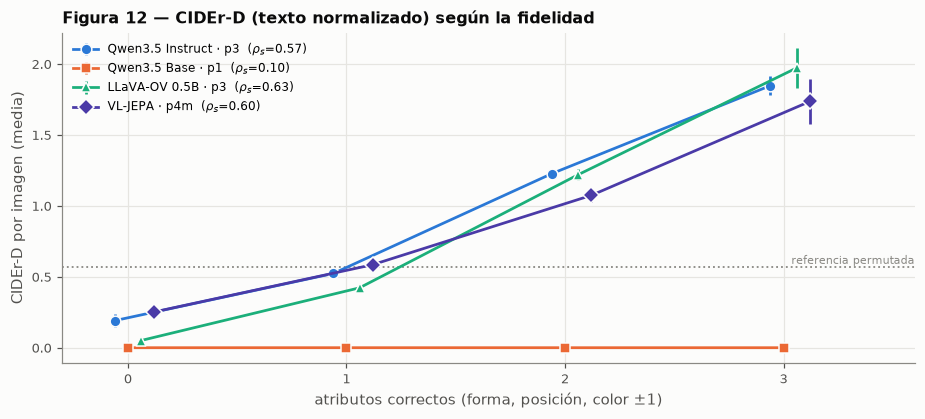

,"ρ Spearman (CIDEr-D, aciertos)"
corrida,
Qwen3.5 Instruct · p3,0.566
Qwen3.5 Base · p1,0.097
LLaVA-OV 0.5B · p3,0.628
VL-JEPA · p4m,0.597


In [29]:
def json_to_template(t):
    o = parse_json_response(strip_think_tags(t or ""))
    if not o:
        return t
    return (f'A "{str(o.get("color", "")).strip()}" {str(o.get("shape", "")).strip()} is at the '
            f'{str(o.get("vertical", "")).strip()}-{str(o.get("horizontal", "")).strip()} of the image.')


tm_rows, PS_NORM = [], {}
ids_top = sorted(common_top)
for r in TOP_RUNS:
    s = top[top["run"] == r].set_index("id").loc[ids_top]
    raw = scorer.per_sample(s["prediction"].tolist(), ids_top)
    norm = scorer.per_sample([json_to_template(t) for t in s["prediction"]], ids_top) if r in JSON_RUNS else raw
    PS_NORM[r] = norm
    for kind, ps in [("original", raw), ("normalizado", norm)]:
        if kind == "normalizado" and r not in JSON_RUNS:
            continue
        tm_rows.append({"corrida": r, "texto": kind, **scorer.summary(ps, B=B_BOOT, seed=SEED)})
order_ = np.random.default_rng(SEED).permutation(len(ids_top))
src_ = np.empty_like(order_); src_[order_] = np.roll(order_, 1)
tpath = truth.set_index("id")
perm = scorer.per_sample(tpath.loc[ids_top, "caption_ref"].values[src_].tolist(), ids_top)
tm_rows.append({"corrida": "Línea base · referencia permutada", "texto": "original", **scorer.summary(perm, B=B_BOOT, seed=SEED)})
tm = pd.DataFrame(tm_rows).set_index(["corrida", "texto"])


def ci(k, sc=100, d=1):
    return lambda row: f"{sc * row[k]:.{d}f} [{sc * row[k + '_lo']:.{d}f}, {sc * row[k + '_hi']:.{d}f}]" if f"{k}_lo" in row else f"{sc * row[k]:.{d}f}"


tm_show = pd.DataFrame({"BLEU-4": tm.apply(ci("bleu"), axis=1), "ROUGE-L": tm.apply(ci("rouge_l"), axis=1),
                        "CIDEr-D": tm.apply(ci("cider_d", 1, 2), axis=1)})
tm_show["Índice macro"] = [f"{100 * M_by.loc[ids_top, r].mean():.1f}" if r in TOP_RUNS else "–" for r, _ in tm.index]
display(tm_show.style.set_caption(f"Métricas de texto con IC 95 % (bootstrap, B={B_BOOT}) · BLEU/ROUGE-L 0–100 · CIDEr-D 0–10"))
save_table(tm, "texto_vs_referencia_top", float_format="%.4f")

fig, ax = plt.subplots(figsize=(8.5, 3.9))
rho_rows = []
for k, r in enumerate(TOP_RUNS):
    lev = np.rint(3 * M_by.loc[ids_top, r].values).astype(int)
    cd = PS_NORM[r]["cider_d"]
    st = pd.DataFrame({"lev": lev, "cd": cd}).groupby("lev")["cd"].agg(["mean", "std", "count"]).reindex(range(4))
    half = Z * st["std"] / np.sqrt(st["count"])
    rho = pd.Series(cd).corr(pd.Series(lev), method="spearman")
    rho_rows.append({"corrida": r, "ρ Spearman (CIDEr-D, aciertos)": rho})
    ax.errorbar(np.arange(4) + (k - 1) * 0.06, st["mean"], yerr=half, fmt=TMK[r] + "-", color=TC[r], ms=7, mec=SURF, lw=1.8,
                capsize=0, label=f"{r}  ($\\rho_s$={rho:.2f})")
ax.axhline(perm["cider_d"].mean(), color=INK3, ls=":", lw=1.2)
ax.text(3.6, perm["cider_d"].mean(), "referencia permutada", fontsize=7.5, color=INK3, va="bottom", ha="right")
ax.set_xticks(range(4), ["0", "1", "2", "3"])
ax.set(xlabel="atributos correctos (forma, posición, color ±1)", ylabel="CIDEr-D por imagen (media)", xlim=(-0.3, 3.6))
ax.legend(fontsize=8, loc="upper left")
ax.set_title("Figura 12 — CIDEr-D (texto normalizado) según la fidelidad", loc="left")
fig.tight_layout()
savefig(fig, "12_texto_vs_fidelidad")
plt.show()
rho_tab = pd.DataFrame(rho_rows).set_index("corrida")
display(rho_tab.style.format("{:.3f}"))

### 6.4 VL-JEPA frente a los modelos generativos

Tres preguntas, un gráfico cada una. La **referencia de otra imagen** (la descripción correcta de una imagen distinta, elegida al azar)
sirve de piso común: es lo que obtiene un sistema que produce descripciones perfectas *del dataset* pero sin mirar la imagen.

1. **¿Cuánto mejor que adivinar?** Puntos porcentuales por encima de la clase mayoritaria, $\hat\alpha_a-\max_k\hat\pi_{a,k}$. Cero = no
   usa la imagen para ese atributo.
2. **¿Cuántas cosas acierta por imagen?** Distribución de $3M_i\in\{0,1,2,3\}$: qué fracción de las imágenes queda completamente bien
   descrita (forma, posición y color correctos a la vez).
3. **¿Parecerse al dataset es describir la imagen?** Similitud textual con la referencia (CIDEr-D) frente a la fidelidad (índice macro).

In [30]:
# Línea base "referencia de otra imagen": misma permutación de §6.3, evaluada con el mismo extractor
_perm_caps = tpath.loc[ids_top, "caption_ref"].values[src_]
_pe = pd.DataFrame([extract(t) for t in _perm_caps], index=ids_top)
_tr = tpath.loc[ids_top]
_ok_s = _pe["shape"].eq(_tr["shape_true"])
_ok_p = _pe["xpos"].eq(_tr["x_true"]) & _pe["ypos"].eq(_tr["y_true"])
_ok_c = pd.Series([cat_distance(a, b) <= 1 for a, b in zip(_pe["color_cat"], _tr["cat_true"])], index=ids_top)
PERM_M = (_ok_s.astype(int) + _ok_p.astype(int) + _ok_c.astype(int)) / 3
PERM_ACC = {"shape": _ok_s.mean(), "pos": _ok_p.mean(), "color_adj": _ok_c.mean(), "macro": PERM_M.mean()}
REF_LAB = "Referencia de otra imagen"

LIFT_ATT = ["shape", "pos", "color_adj", "macro"]
lift = pd.DataFrame({a: [(W[a][r].astype(float).mean() if a != "macro" else M_by.loc[ids_top, r].mean()) - MAJ[a]
                         for r in TOP_RUNS] for a in LIFT_ATT}, index=TOP_RUNS)
lift.loc[REF_LAB] = [PERM_ACC[a] - MAJ[a] for a in LIFT_ATT]
display((100 * lift).rename(columns=ATT_ES).style.format("{:+.1f}").background_gradient(cmap=DIV, vmin=-60, vmax=60, axis=None)
        .set_caption("Puntos porcentuales sobre la clase mayoritaria"))
save_table(lift, "vljepa_puntos_sobre_azar")

,Forma,"Posición (x,y)",Color ±1,Índice macro
Qwen3.5 Instruct · p3,+29.0,+26.4,+48.7,+34.7
Qwen3.5 Base · p1,+2.7,+31.1,+47.5,+27.1
LLaVA-OV 0.5B · p3,+23.1,-0.5,+41.2,+21.3
VL-JEPA · p4m,+12.1,+4.1,-5.7,+3.5
Referencia de otra imagen,-0.3,-1.0,-12.2,-4.5


**Figura 13 — ¿Cuánto mejor que adivinar?** Cada barra es la exactitud menos la de responder siempre la clase más frecuente. La barra
gris es la referencia de otra imagen: cualquier barra de su largo o menor no aporta información de la imagen. Un valor **negativo** es
posible y no es un error: significa acertar menos que la mejor respuesta fija (en *Color ±1* la mejor respuesta fija ya cubre tres de las
ocho categorías, ≈50 % de las imágenes, mientras que nombrar colores al azar acierta bastante menos).

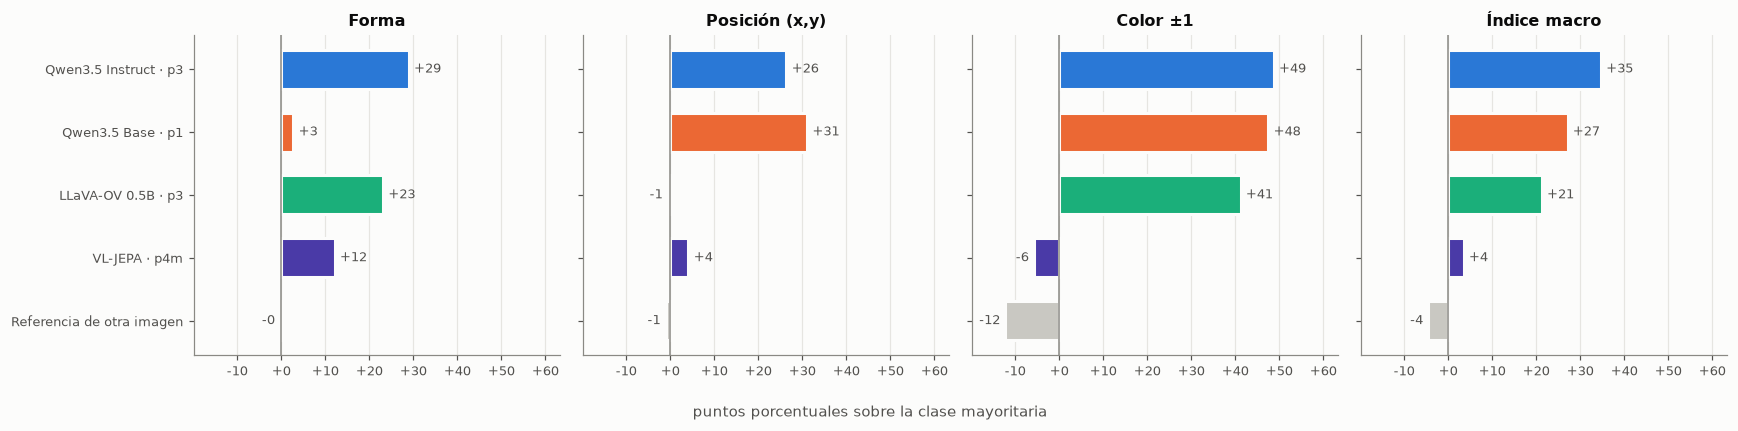

In [31]:
rows_ = TOP_RUNS + [REF_LAB]
fig, axes = plt.subplots(1, len(LIFT_ATT), figsize=(3.6 * len(LIFT_ATT) + 1.5, 0.48 * len(rows_) + 1.5), sharey=True)
xmax_ = max(0.1, float(np.nanmax(lift.values)) * 1.3)
xmin_ = min(0.0, float(np.nanmin(lift.values)) * 1.3) - 0.04
for ax, a in zip(axes, LIFT_ATT):
    for k, r in enumerate(rows_):
        v = lift.at[r, a]
        ax.barh(k, v, height=0.62, color=TC.get(r, NEUTRAL), edgecolor=SURF, linewidth=2)
        ax.text(v + (0.012 if v >= 0 else -0.012), k, f"{100 * v:+.0f}", va="center", ha="left" if v >= 0 else "right",
                fontsize=8.5, color=INK2)
    ax.axvline(0, color=INK3, lw=1)
    ax.set(xlim=(xmin_, xmax_), title=ATT_ES[a])
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{100 * v:+.0f}"))
    ax.grid(axis="y", visible=False)
axes[0].set_yticks(range(len(rows_)), rows_); axes[0].invert_yaxis()
fig.supxlabel("puntos porcentuales sobre la clase mayoritaria", fontsize=9.5, color=INK2)
fig.tight_layout()
savefig(fig, "13_puntos_sobre_azar")
plt.show()

**Figura 14 — ¿Cuántos atributos acierta por imagen?** Cada barra reparte las $N$ imágenes según cuántos de los tres atributos (forma,
posición, color ±1) quedan correctos. El tramo más oscuro es la fracción de imágenes descritas **completamente bien**.

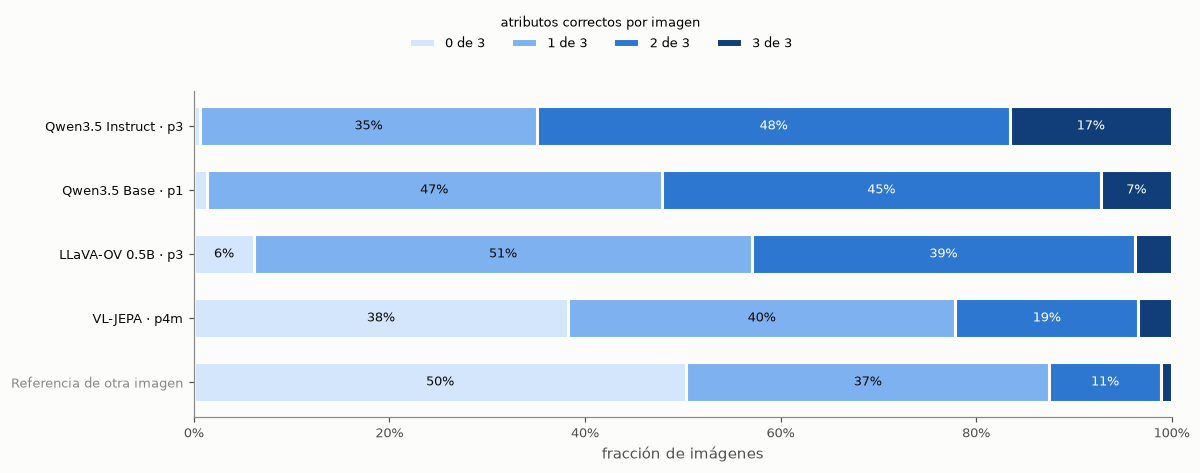

,0 de 3,1 de 3,2 de 3,3 de 3
Qwen3.5 Instruct · p3,0.6,34.6,48.3,16.6
Qwen3.5 Base · p1,1.3,46.5,44.9,7.2
LLaVA-OV 0.5B · p3,6.2,50.9,39.2,3.8
VL-JEPA · p4m,38.2,39.6,18.7,3.4
Referencia de otra imagen,50.4,37.1,11.4,1.1


In [32]:
lev_tab = pd.DataFrame({r: pd.Series(np.rint(3 * M_by.loc[ids_top, r].values).astype(int)).value_counts(normalize=True)
                        .reindex(range(4), fill_value=0) for r in TOP_RUNS}).T
lev_tab.loc[REF_LAB] = pd.Series(np.rint(3 * PERM_M.values).astype(int)).value_counts(normalize=True).reindex(range(4), fill_value=0)
LEV_COL = [SEQ(x) for x in (0.12, 0.38, 0.65, 0.95)]
fig, ax = plt.subplots(figsize=(11, 0.55 * len(lev_tab) + 1.6))
for k, r in enumerate(lev_tab.index):
    left = 0.0
    for j in range(4):
        v = lev_tab.at[r, j]
        ax.barh(k, v, left=left, height=0.62, color=LEV_COL[j], edgecolor=SURF, linewidth=2, label=f"{j} de 3" if k == 0 else None)
        if v >= 0.05:
            ax.text(left + v / 2, k, f"{v:.0%}", ha="center", va="center", fontsize=8.5, color="white" if j >= 2 else INK)
        left += v
ax.set_yticks(range(len(lev_tab)), lev_tab.index); ax.invert_yaxis()
for t, r in zip(ax.get_yticklabels(), lev_tab.index):
    t.set_color(INK if r in TOP_RUNS else INK3)
ax.set(xlim=(0, 1), xlabel="fracción de imágenes"); ax.xaxis.set_major_formatter(PCT); ax.grid(False)
h, l = ax.get_legend_handles_labels()
fig.tight_layout(rect=(0, 0, 1, 0.84))
fig.legend(h, l, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 0.99), title="atributos correctos por imagen", title_fontsize=8.5)
savefig(fig, "14_aciertos_por_imagen")
plt.show()
display((100 * lev_tab).rename(columns=lambda j: f"{j} de 3").style.format("{:.1f}"))
save_table(lev_tab, "aciertos_por_imagen")

**Figura 15 — ¿Parecerse al dataset es describir la imagen?** Eje x: similitud textual con la referencia (CIDEr-D; en los prompts JSON,
con el texto normalizado a la plantilla). Eje y: fidelidad (índice macro). Un sistema que "habla como el dataset" sin mirar la imagen
queda **a la derecha y abajo**, cerca de la referencia de otra imagen; uno fiel queda **arriba**. Las barras son IC 95 %.

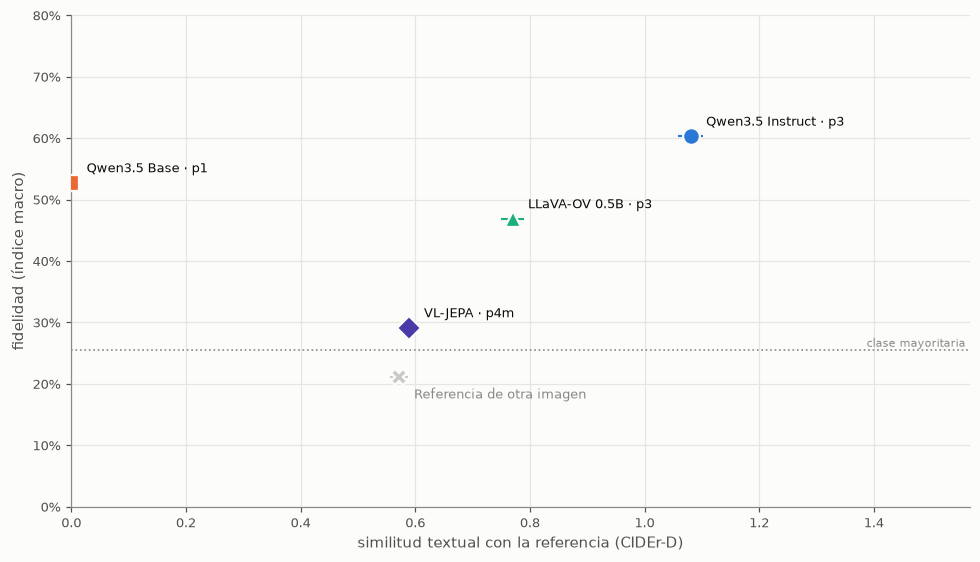

,cider,cider_se,macro,macro_se
Qwen3.5 Instruct · p3,1.08,0.011,60.3%,0.24%
Qwen3.5 Base · p1,0.00,0.000,52.7%,0.21%
LLaVA-OV 0.5B · p3,0.77,0.010,46.8%,0.22%
VL-JEPA · p4m,0.59,0.008,29.1%,0.28%
Referencia de otra imagen,0.57,0.008,21.1%,0.24%


In [33]:
_n = len(ids_top)
sim_fid = pd.DataFrame({
    "cider": [PS_NORM[r]["cider_d"].mean() for r in TOP_RUNS] + [perm["cider_d"].mean()],
    "cider_se": [PS_NORM[r]["cider_d"].std(ddof=1) / np.sqrt(_n) for r in TOP_RUNS] + [perm["cider_d"].std(ddof=1) / np.sqrt(_n)],
    "macro": [M_by.loc[ids_top, r].mean() for r in TOP_RUNS] + [PERM_M.mean()],
    "macro_se": [M_by.loc[ids_top, r].std(ddof=1) / np.sqrt(_n) for r in TOP_RUNS] + [PERM_M.std(ddof=1) / np.sqrt(_n)],
}, index=TOP_RUNS + [REF_LAB])
fig, ax = plt.subplots(figsize=(9, 5.2))
for r in sim_fid.index:
    row, is_ref = sim_fid.loc[r], r == REF_LAB
    ax.errorbar(row["cider"], row["macro"], xerr=Z * row["cider_se"], yerr=Z * row["macro_se"],
                fmt="X" if is_ref else TMK[r], color=NEUTRAL if is_ref else TC[r], ms=11, mec=SURF, mew=1.5,
                elinewidth=1.4, capsize=0, zorder=3)
    ax.annotate(r, (row["cider"], row["macro"]), xytext=(10, -14 if is_ref else 7), textcoords="offset points", fontsize=8.5,
                color=INK3 if is_ref else INK)
ax.set(xlim=(0, sim_fid["cider"].max() * 1.45), ylim=(0, max(0.8, sim_fid["macro"].max() + 0.1)),
       xlabel="similitud textual con la referencia (CIDEr-D)", ylabel="fidelidad (índice macro)")
ax.axhline(MAJ["macro"], color=INK3, ls=":", lw=1.1)
ax.text(ax.get_xlim()[1], MAJ["macro"], "clase mayoritaria ", fontsize=7.5, color=INK3, va="bottom", ha="right")
ax.yaxis.set_major_formatter(PCT)
fig.tight_layout()
savefig(fig, "15_similitud_vs_fidelidad")
plt.show()
display(sim_fid.style.format({"cider": "{:.2f}", "cider_se": "{:.3f}", "macro": "{:.1%}", "macro_se": "{:.2%}"}))
save_table(sim_fid, "similitud_vs_fidelidad")

## 7. Ejemplos, síntesis y exportación

### 7.1 Ejemplos cualitativos

Imágenes elegidas al azar (semilla fija) en tres estratos según la forma: **todas** las configuraciones aciertan, **ninguna** acierta, y
**discrepan**.

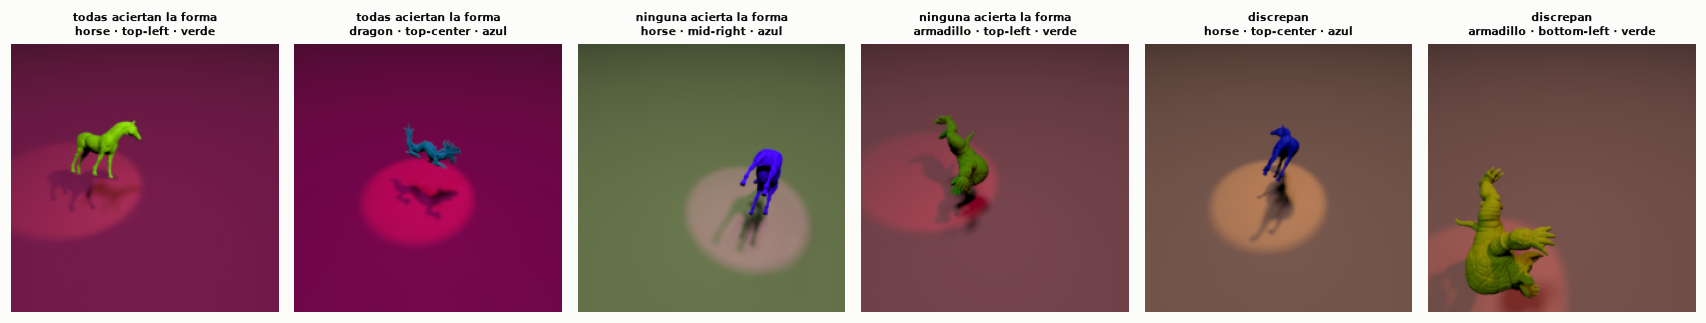

**base/test/8716** · *todas aciertan la forma* — referencia: *The top-left of the image shows a "lawngreen" colored horse.*  
verdad: horse, top-left, tono verde (`lawngreen`)

,respuesta,forma,pos,color±1
corrida,,,,
Qwen3.5 Instruct · p3,"```json [ { ""shape"": ""horse"", ""color"": ""green"", ""vertical"": ""top"", ""horizontal"": ""left"" } ] ```",✓,✓,✓
Qwen3.5 Base · p1,"**Description of the object:** The object in this image is a stylized, 3D-rendered representation of a horse. It is ...",✓,✓,✓
LLaVA-OV 0.5B · p3,"{""shape"": ""horse"", ""color"": ""green"", ""vertical"": ""top"", ""horizontal"": ""right""}",✓,✗,✓
VL-JEPA · p4m,"The top-center of the image shows a ""tab:cyan"" colored horse.",✓,✗,✓


**base/test/3491** · *todas aciertan la forma* — referencia: *A dragon of "tab:cyan" color is visible, positioned at the top-center of the image.*  
verdad: dragon, top-center, tono azul (`tab:cyan`)

,respuesta,forma,pos,color±1
corrida,,,,
Qwen3.5 Instruct · p3,"```json [ { ""shape"": ""dragon"", ""color"": ""blue"", ""vertical"": ""top"", ""horizontal"": ""right"" } ] ```",✓,✗,✓
Qwen3.5 Base · p1,"**Description of the object:** The object in the image is a small, blue, stylized creature resembling a dragon or a ...",✓,✓,✓
LLaVA-OV 0.5B · p3,"{""shape"": ""dragon"", ""color"": ""blue"", ""vertical"": ""top"", ""horizontal"": ""right""}",✓,✗,✓
VL-JEPA · p4m,"The mid-right of the image shows a ""xkcd:neon red"" colored dragon.",✓,✗,✗


**base/test/0980** · *ninguna acierta la forma* — referencia: *A "xkcd:primary blue" horse is at the mid-right of the image.*  
verdad: horse, mid-right, tono azul (`xkcd:primary blue`)

...

,respuesta,forma,pos,color±1
corrida,,,,
Qwen3.5 Instruct · p3,"```json [ { ""shape"": ""dragon"", ""color"": ""green"", ""vertical"": ""top"", ""horizontal"": ""left"" } ] ```",✗,✓,✓
Qwen3.5 Base · p1,"**Description of the Object** * **Shape:** The object is a small, green, dinosaur-like creature. It appears to be a ...",✗,✗,✓
LLaVA-OV 0.5B · p3,"{""shape"": ""dragon"", ""color"": ""green"", ""vertical"": ""top"", ""horizontal"": ""right""}",✗,✗,✓
VL-JEPA · p4m,"The mid-center of the image shows a ""xkcd:neon green"" colored dragon.",✗,✗,✓


**base/test/1562** · *discrepan* — referencia: *At the top-center of the image, there is a "blue" object in the form of a horse.*  
verdad: horse, top-center, tono azul (`blue`)

,respuesta,forma,pos,color±1
corrida,,,,
Qwen3.5 Instruct · p3,"```json [ { ""shape"": ""horse"", ""color"": ""blue"", ""vertical"": ""top"", ""horizontal"": ""left"" } ] ```",✓,✗,✓
Qwen3.5 Base · p1,"**Description of the object:** The object in the image is a small, blue, humanoid figure. It appears to be a stylize...",✗,✗,✓
LLaVA-OV 0.5B · p3,"{""shape"": ""hare"", ""color"": ""blue"", ""vertical"": ""top"", ""horizontal"": ""right""}",✗,✗,✓
VL-JEPA · p4m,"A ""deepskyblue"" head is at the mid-center of the image.",✗,✗,✓


**base/test/2864** · *discrepan* — referencia: *A "xkcd:lime green" armadillo is at the bottom-left of the image.*  
verdad: armadillo, bottom-left, tono verde (`xkcd:lime green`)

,respuesta,forma,pos,color±1
corrida,,,,
Qwen3.5 Instruct · p3,"```json [ { ""shape"": ""armadillo"", ""color"": ""green"", ""vertical"": ""bottom"", ""horizontal"": ""left"" }, { ""shape"": ""armadi...",✓,✓,✓
Qwen3.5 Base · p1,"**Shape:** The object is a small, green, 3D model resembling a stylized insect or bug. It has a segmented body with ...",✗,✓,✓
LLaVA-OV 0.5B · p3,"{""shape"": ""dragon"", ""color"": ""green"", ""vertical"": ""top"", ""horizontal"": ""right""}",✗,✗,✓
VL-JEPA · p4m,"A ""xkcd:electric pink"" armadillo is at the bottom-right of the image.",✓,✗,✗


In [34]:
N_PER = 2
Ssh = W["shape"][TOP_RUNS].astype(bool).sum(axis=1)
strata = {"todas aciertan la forma": Ssh[Ssh == len(TOP_RUNS)].index, "ninguna acierta la forma": Ssh[Ssh == 0].index,
          "discrepan": Ssh[(Ssh > 0) & (Ssh < len(TOP_RUNS))].index}
picks = [(lab, str(i)) for lab, ix in strata.items() for i in RNG.choice(sorted(ix), size=min(N_PER, len(ix)), replace=False)]
root = data_root(VARIANT)
if picks and (root / tpath.at[picks[0][1], "image_path"]).exists():
    from PIL import Image
    fig, axes = plt.subplots(1, len(picks), figsize=(2.6 * len(picks), 3.1))
    for ax, (lab, i) in zip(np.atleast_1d(axes), picks):
        ax.imshow(Image.open(root / tpath.at[i, "image_path"]))
        ax.set_title(f"{lab}\n{tpath.at[i, 'shape_true']} · {tpath.at[i, 'y_true']}-{tpath.at[i, 'x_true']} · "
                     f"{COLOR_ES[tpath.at[i, 'cat_true']]}", fontsize=7.5)
        ax.axis("off")
    fig.tight_layout()
    savefig(fig, "16_ejemplos")
    plt.show()
else:
    print(f"(imágenes no disponibles en {root}; se muestran solo los textos)")
tix = top.set_index(["id", "run"])
for lab, i in picks:
    display(Markdown(f"**{i}** · *{lab}* — referencia: *{tpath.at[i, 'caption_ref']}*  \n"
                     f"verdad: {tpath.at[i, 'shape_true']}, {tpath.at[i, 'y_true']}-{tpath.at[i, 'x_true']}, "
                     f"tono {COLOR_ES[tpath.at[i, 'cat_true']]} (`{tpath.at[i, 'name_true']}`)"))
    rows = []
    for r in TOP_RUNS:
        x_ = tix.loc[(i, r)]
        rows.append({"corrida": r, "respuesta": " ".join(strip_think_tags(x_["prediction"]).split())[:200],
                     "forma": "✓" if x_["shape_ok"] else "✗", "pos": "✓" if x_["pos_ok"] else "✗",
                     "color±1": "✓" if x_["color_adj"] else "✗"})
    display(pd.DataFrame(rows).set_index("corrida"))

### 7.2 Síntesis

El resumen se genera con los valores de este notebook; las afirmaciones cualitativas de abajo solo se sostienen si las cifras lo confirman.

In [35]:
def best_of(a):
    r = max(TOP_RUNS, key=lambda r: W[a][r].mean())
    return r, W[a][r].mean()


mac = {r: M_by.loc[ids_top, r].mean() for r in TOP_RUNS}
GEN = [r for r in TOP_RUNS if r != VJ_RUN]
worst_att = min(["shape", "pos", "color_adj"], key=lambda a: np.mean([W[a][r].mean() for r in TOP_RUNS]))
conf_all = top[top["shape_m"] & ~top["shape_ok"]].groupby(["shape_true", "shape"]).size().sort_values(ascending=False)
tc, pc = conf_all.index[0] if len(conf_all) else ("–", "–")
nxt = sel.loc[TOP_K, ["Δ vs. siguiente", "IC Δ", "separado"]] if TOP_K < len(sel) else None
lines = [
    f"* **Selección.** " + "; ".join(f"**{k + 1}.** {r} (macro {mac[r]:.1%})" for k, r in enumerate(TOP3)) + "."
    + (f" El {TOP_K}.º supera al {TOP_K + 1}.º por {nxt['Δ vs. siguiente']:+.1%} {nxt['IC Δ']}"
       + (" (separación significativa)." if nxt["separado"] == "✓" else " (no separable del siguiente).") if nxt is not None else ""),
    "* **Mejor por atributo.** " + "; ".join(f"{ATT_ES[a]}: {best_of(a)[0]} ({best_of(a)[1]:.1%})" for a in ["shape", "pos", "color_adj"]) + ".",
    f"* **Atributo más difícil.** {ATT_ES[worst_att]} (media de las configuraciones: "
    f"{np.mean([W[worst_att][r].mean() for r in TOP_RUNS]):.1%}; clase mayoritaria {MAJ[worst_att]:.1%}).",
] + ([
    f"* **VL-JEPA ({VJ_RUN}).** Macro {mac[VJ_RUN]:.1%} frente a {mac[GEN[0]]:.1%} del mejor generativo y {MAJ['macro']:.1%} de la clase "
    f"mayoritaria. Puntos sobre el azar — " + ", ".join(f"{ATT_ES[a]}: {100 * lift.loc[VJ_RUN, a]:+.1f}" for a in ["shape", "pos", "color_adj"])
    + f". Similitud textual (CIDEr-D) {sim_fid.loc[VJ_RUN, 'cider']:.2f} vs. {sim_fid.loc[REF_LAB, 'cider']:.2f} "
    "de la referencia de otra imagen.",
] if VJ_RUN else []) + [
    f"* **Confusión de forma más frecuente** (sumando todas): {tc} → {pc}.",
    f"* **Errores compartidos (forma).** Ninguna acierta en {shared.iloc[0, 0]:.1%} de las imágenes frente a {shared.iloc[0, 1]:.1%} "
    f"esperado bajo independencia (p = {shared.iloc[0]['p (S=0)']:.2g})"
    + (" → hay imágenes difíciles para todas las configuraciones." if shared.iloc[0, 0] > shared.iloc[0, 1] and shared.iloc[0]["p (S=0)"] < ALPHA
       else " → no hay evidencia de dificultad compartida más allá de las tasas marginales."),
    "* **Texto vs. fidelidad.** ρ de Spearman entre CIDEr-D por imagen y número de aciertos: "
    + ", ".join(f"{r} {v:.2f}" for r, v in rho_tab.iloc[:, 0].items()) + ".",
]
display(Markdown("\n".join(lines)))

* **Selección.** **1.** Qwen3.5 Instruct · p3 (macro 60.3%); **2.** Qwen3.5 Base · p1 (macro 52.7%); **3.** LLaVA-OV 0.5B · p3 (macro 46.8%). El 3.º supera al 4.º por +3.5% [+2.9%, +4.1%] (separación significativa).
* **Mejor por atributo.** Forma: Qwen3.5 Instruct · p3 (43.5%); Posición (x,y): Qwen3.5 Base · p1 (43.0%); Color ±1: Qwen3.5 Instruct · p3 (99.0%).
* **Atributo más difícil.** Posición (x,y) (media de las configuraciones: 27.2%; clase mayoritaria 11.9%).
* **VL-JEPA (VL-JEPA · p4m).** Macro 29.1% frente a 60.3% del mejor generativo y 25.6% de la clase mayoritaria. Puntos sobre el azar — Forma: +12.1, Posición (x,y): +4.1, Color ±1: -5.7. Similitud textual (CIDEr-D) 0.59 vs. 0.57 de la referencia de otra imagen.
* **Confusión de forma más frecuente** (sumando todas): hare → head.
* **Errores compartidos (forma).** Ninguna acierta en 26.7% de las imágenes frente a 21.4% esperado bajo independencia (p = 4.7e-39) → hay imágenes difíciles para todas las configuraciones.
* **Texto vs. fidelidad.** ρ de Spearman entre CIDEr-D por imagen y número de aciertos: Qwen3.5 Instruct · p3 0.57, Qwen3.5 Base · p1 0.10, LLaVA-OV 0.5B · p3 0.63, VL-JEPA · p4m 0.60.

**Limitaciones.**

1. **Selección sobre test.** Las tres configuraciones generativas se eligen con el mismo conjunto en que se evalúan; la exactitud de la mejor está
   sesgada al alza (sesgo de selección entre 30 corridas). Con $N=10^4$ y diferencias de varios puntos el orden es robusto, pero las
   cifras absolutas deben confirmarse en *val* o en las variantes OOD antes de la Etapa 2.
2. **Extractor léxico.** Validado sobre las referencias (§2), cuyo lenguaje es regular. En texto libre puede omitir sinónimos o asignar
   mal un color al fondo; la exactitud condicional de §4.2 acota ese efecto, no lo elimina.
3. **Color ±1 es tolerante.** Dos categorías vecinas cubren hasta ~155° del círculo; la exactitud estricta de categoría y el nombre exacto
   son cotas más exigentes.
4. **VL-JEPA no es comparable 1:1.** Recupera captions de un banco de *train* con un checkpoint entrenado en MSRVTT (video): mide qué
   información de la escena conserva su *embedding*, no su capacidad de redactar. Su exactitud está acotada por la cobertura del banco.
5. **Comparaciones múltiples.** Los $p$-valores de §6.1 se ajustan por Holm dentro de la tabla, no frente a todo lo explorado en los
   notebooks 02–03.

In [36]:
keep = ["exp_id", "run", "model", "prompt", "id", "prediction", "shape", "shape_true", "shape_ok", "xpos", "ypos", "x_true", "y_true",
        "pos_ok", "color_name", "color_cat", "cat_true", "name_true", "color_ok", "color_adj", "name_ok", "hue_err", "dh_bg",
        "n_words", "json_ok", "macro"]
out = top[keep].copy()
out["run"] = out["run"].astype(str)
out["json_ok"] = out["json_ok"].astype("boolean")
out.to_parquet(TAB_DIR / "top_atributos.parquet", index=False)
print("Tablas:", sorted(p.name for p in TAB_DIR.iterdir()))
print("Figuras:", sorted(p.name for p in FIG_DIR.glob("*.png")))

Tablas: ['aciertos_por_imagen.csv', 'aciertos_por_imagen.tex', 'fidelidad_top_largo.csv', 'fidelidad_top_largo.tex', 'integridad_corridas.csv', 'integridad_corridas.tex', 'panorama_30_corridas.csv', 'panorama_30_corridas.tex', 'pareadas_top.csv', 'pareadas_top.tex', 'seleccion_top.csv', 'seleccion_top.tex', 'similitud_vs_fidelidad.csv', 'similitud_vs_fidelidad.tex', 'texto_top.csv', 'texto_top.tex', 'texto_vs_referencia_top.csv', 'texto_vs_referencia_top.tex', 'top_atributos.parquet', 'vljepa_puntos_sobre_azar.csv', 'vljepa_puntos_sobre_azar.tex']
Figuras: ['01_panorama_seleccion.png', '02_largo_respuestas.png', '03_exactitud_atributos.png', '04_descomposicion.png', '05_confusion_forma.png', '06_forma_por_clase.png', '07_posicion.png', '08_color.png', '09_confusion_color.png', '10_dificultad.png', '11_errores_compartidos.png', '12_texto_vs_fidelidad.png', '13_ejemplos.png', '13_puntos_sobre_azar.png', '14_aciertos_por_imagen.png', '15_similitud_vs_fidelidad.png', '16_ejemplos.png']
